# Married and Divorced Survey EDA
This notebook presents exploratory data analysis on the marriage/divorced survey data, with the intention of identifying stronger features to be used in modelling to predict marriage/divorce for couples.

## Analysis flow
1. Data load and initial checks
2. Demographic patterns (age, family background, prior marriage)
3. Pre-marital origins and relationship history
4. Beliefs, values, and in-law relationships
5. Personality and lifestyle factors
6. Top-3 values alignment engineering
7. Feature-store export for modelling

**Important note:** findings are associative (not causal). Statistical tests are interpreted together with effect sizes and sample sparsity checks.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import itertools
import warnings
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact, spearmanr

# Suppress non-actionable matplotlib glyph warnings from emoji/special characters in labels
warnings.filterwarnings(
    "ignore",
    message=r"Glyph .* missing from font\(s\) DejaVu Sans\.",
    category=UserWarning
)

divorced = pd.read_csv(
    r'/Users/clairesng/Downloads/capstone_divorced/divorced.csv',
    encoding='latin1'
)

print(f"Shape: {divorced.shape}")
divorced.head()

Shape: (120, 28)


,Timestamp,What is your current marital status?,Wife: How old were you at marriage? (in years),Husband: How old were you at marriage? (in years),Our Family Backgrounds:,Have you been married before?,Was buying a home or moving out a significant factor for marriage?,How did you meet?,How long was your relationship before marriage?,Did you attend Premarital Counselling?,...,Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [Your spouse/ex and their in-laws],Our household is primarily:,On managing household finances:,What best describes your personalities?,Do you share a key common interest?,Do you approve of each other's social circle?,How do you feel about pets & pet ownership?,Which top 3 values do you prioritise most in your life? [Me],Which top 3 values do you prioritise most in your life? [My spouse/ex],"Thank you for reaching the end! \n\nIf there are there any other factors you feel are important for a relationship that were not mentioned, feel free to add them here. Otherwise, press submit!"
0,2/12/2026 18:58:26,Divorced or Annulled,25,27,Both our parents are Divorced,No,No,Mutual friends,6 monthsâ1 year,No,...,Bad,Dual income,"Half aligned, half in disagreement",Mixed - One of each,No,Somewhat,We are both indifferent or do not want pets,"Self-Improvement, Health and Fitness, Community","Career Ambition, Family, Security/Stability",NaN
1,2/13/2026 20:30:11,Married or Widowed,25,26,Both our parents are Married,No,No,Family introduction,<6 months,No,...,Bad,Single income,Mostly aligned,Both Introverts,Yes,Yes,"Mixed - One of us love pets, the other does not","Career Ambition, Family, Security/Stability","Family, Security/Stability, Health and Fitness",\nHow is your sex life? How well do you commu...
2,2/14/2026 13:50:01,Married or Widowed,41,41,Both our parents are Divorced,No,Yes,Online (e.g. Dating App),4+ years,Yes,...,Neutral,Single income,"Half aligned, half in disagreement",Mixed - One of each,Yes,Somewhat,We are both indifferent or do not want pets,"Family, Faith and Spirituality, Security/Stabi...","Career Ambition, Adventure/Trying New Things, ...",NaN
3,2/14/2026 16:47:29,Married or Widowed,36,33,Both our parents are Married,No,No,Mutual friends,2â4 years,No,...,Very Good,Dual income,Mostly aligned,Mixed - One of each,Yes,Yes,We both love and/or own pets,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Self-Improvement",NaN
4,2/14/2026 17:53:13,Married or Widowed,25,26,Both our parents are Married,No,No,Met in USA,4+ years,No,...,Good,Dual income,Mostly aligned,Mixed - One of each,No,Yes,We are both indifferent or do not want pets,"Career Ambition, Family, Faith and Spirituality","Career Ambition, Family, Faith and Spirituality",NaN


## 1) Demographic Overview
This section profiles baseline respondent differences by marital outcome.

Focus areas:
- Current marital status
- Age at marriage (wife and husband)
- Family background
- Whether either spouse was previously married

### 1.1 Age at marriage: raw-value checks and cleaning setup
We first inspect age fields, clean malformed entries, and prepare them for analysis.

In [8]:
wife_age    = 'Wife: How old were you at marriage? (in years)'
husband_age = 'Husband: How old were you at marriage? (in years)'

# Check raw unique values before touching anything
display("Wife unique values:", sorted(divorced[wife_age].dropna().unique()))
display("Husband unique values:", sorted(divorced[husband_age].dropna().unique()))

'Wife unique values:'

['19',
 '20',
 '22',
 '23',
 '24',
 '24 yrs old',
 '25',
 '26',
 '27',
 '27 years',
 '28',
 '29',
 '30',
 '31',
 '31 yrs ',
 '32',
 '33',
 '34',
 '35',
 '36',
 '40',
 '40s',
 '41',
 '5']

'Husband unique values:'

['20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '27 yrs old',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40s',
 '41',
 '42',
 '5']

In [9]:
# Extract numbers only (strip text like "yrs", "years", etc.)

divorced[wife_age]    = divorced[wife_age].astype(str).str.extract(r'(\d+)', expand=False).astype(float)
divorced[husband_age] = divorced[husband_age].astype(str).str.extract(r'(\d+)', expand=False).astype(float)

In [10]:
# Flag the suspicious row(s)
print("Rows with age ≤ 10:")
print(divorced[(divorced[wife_age] <= 10) | (divorced[husband_age] <= 10)][
    [wife_age, husband_age, 'What is your current marital status?']
])

# Replace with NaN — treat as erroneous entry, will be filled by median in next step
divorced.loc[divorced[wife_age]    <= 10, wife_age]    = np.nan
divorced.loc[divorced[husband_age] <= 10, husband_age] = np.nan


Rows with age ≤ 10:
    Wife: How old were you at marriage? (in years)  \
37                                             5.0   

    Husband: How old were you at marriage? (in years)  \
37                                                5.0   

   What is your current marital status?  
37                   Married or Widowed  


In [11]:
# Check total nulls before filling 
print(f"Nulls — Wife: {divorced[wife_age].isnull().sum()} | Husband: {divorced[husband_age].isnull().sum()}")
print(divorced[divorced[wife_age].isnull() | divorced[husband_age].isnull()][[wife_age, husband_age]])

Nulls — Wife: 2 | Husband: 2
    Wife: How old were you at marriage? (in years)  \
37                                             NaN   
50                                            27.0   
60                                             NaN   

    Husband: How old were you at marriage? (in years)  
37                                                NaN  
50                                                NaN  
60                                               30.0  


In [12]:
# ── Descriptive Statistics: Wife Age, Husband Age, Age Gap ───────────────────

# Compute age gap (absolute difference)
divorced['Age Gap (years)'] = (divorced[husband_age] - divorced[wife_age]).abs()

# Descriptive stats for all three
stats = divorced[[wife_age, husband_age, 'Age Gap (years)']].describe().T
stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
stats = stats.round(2)

print("── Descriptive Statistics ───────────────────────────────────────────────")
print(stats.to_string())

stats

── Descriptive Statistics ───────────────────────────────────────────────
                                                   Count   Mean  Std Dev   Min   25%  Median    75%   Max
Wife: How old were you at marriage? (in years)     118.0  27.58     4.41  19.0  25.0    28.0  30.75  41.0
Husband: How old were you at marriage? (in years)  118.0  29.71     4.29  20.0  27.0    29.0  32.00  42.0
Age Gap (years)                                    117.0   2.38     1.94   0.0   1.0     2.0   3.00  12.0


,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Wife: How old were you at marriage? (in years),118.0,27.58,4.41,19.0,25.0,28.0,30.75,41.0
Husband: How old were you at marriage? (in years),118.0,29.71,4.29,20.0,27.0,29.0,32.00,42.0
Age Gap (years),117.0,2.38,1.94,0.0,1.0,2.0,3.00,12.0


### 1.2 Imputation rationale
Missing/suspicious age entries are imputed with spouse-specific medians.

Reasoning:
- Median is robust to outliers
- Group distributions are centered near those medians
- The clearly erroneous age value is treated as a data-entry issue
- Median in sample is close to median in population (Singapore)

In [13]:
# Impute null values with the median ages of the respective spouse
wife_median    = divorced[wife_age].median()
husband_median = divorced[husband_age].median()

#'df.method({col: value}, inplace=True)'
divorced.fillna({wife_age: wife_median, husband_age: husband_median}, inplace=True)

divorced[wife_age]    = divorced[wife_age].astype(int)
divorced[husband_age] = divorced[husband_age].astype(int)

── Descriptive Statistics ───────────────────────────────────────────────
                                                   Count   Mean  Std Dev   Min   25%  Median    75%   Max
Wife: How old were you at marriage? (in years)     120.0  27.59     4.38  19.0  25.0    28.0  30.25  41.0
Husband: How old were you at marriage? (in years)  120.0  29.70     4.25  20.0  27.0    29.0  32.00  42.0
age_gap                                            120.0   2.11     2.20  -4.0   1.0     2.0   3.00  12.0



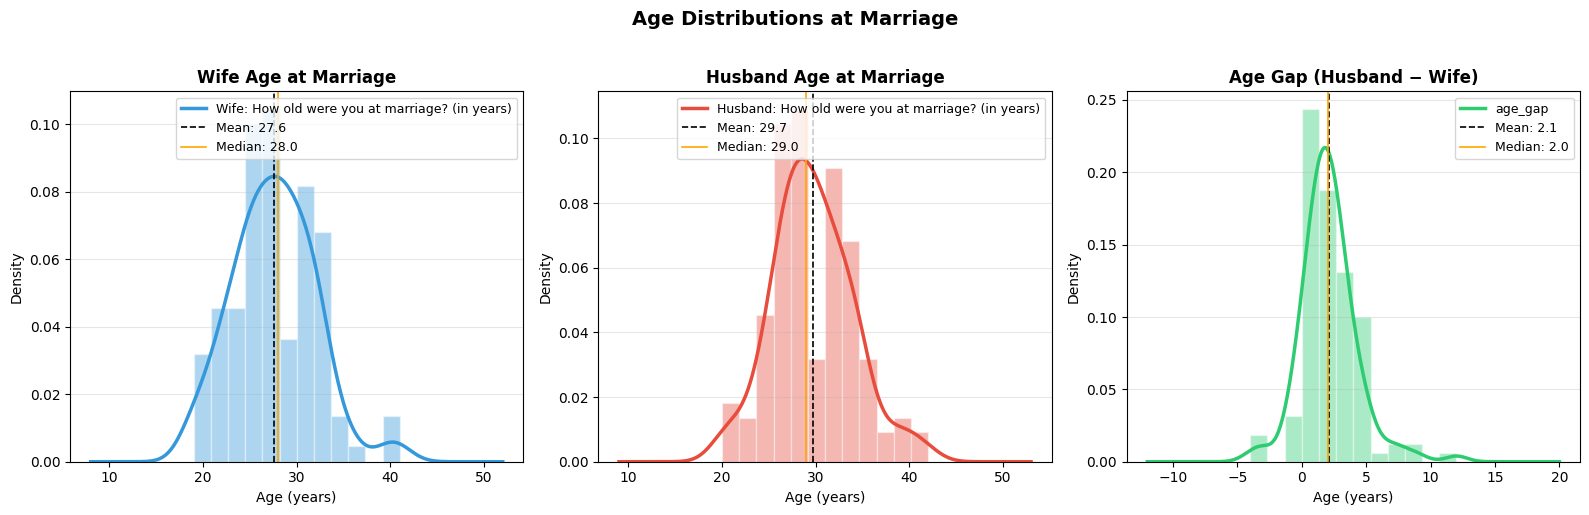

,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Wife: How old were you at marriage? (in years),120.0,27.59,4.38,19.0,25.0,28.0,30.25,41.0
Husband: How old were you at marriage? (in years),120.0,29.70,4.25,20.0,27.0,29.0,32.00,42.0
age_gap,120.0,2.11,2.20,-4.0,1.0,2.0,3.00,12.0


In [14]:
# ── Age Gap & Descriptive Statistics for whole dataset ────────────────────────
divorced['age_gap'] = divorced[husband_age] - divorced[wife_age]

# ── Descriptive Statistics ────────────────────────────────────────────────────
stats = divorced[[wife_age, husband_age, 'age_gap']].describe().T
stats.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
print("── Descriptive Statistics ───────────────────────────────────────────────")
print(stats.round(2).to_string())
print()

# ── Distribution Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_config = [
    (wife_age,    'age_gap' in divorced.columns and divorced[wife_age],    '#3498db', 'Wife Age at Marriage'),
    (husband_age, divorced[husband_age], '#e74c3c', 'Husband Age at Marriage'),
    ('age_gap',   divorced['age_gap'],   '#2ecc71', 'Age Gap (Husband − Wife)'),
]

for ax, (col, _, color, title) in zip(axes, plot_config):
    data = divorced[col]
    
    ax.hist(data, bins=12, color=color, alpha=0.4, edgecolor='white', density=True)
    data.plot.kde(ax=ax, color=color, linewidth=2.5)
    
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.2, label=f'Median: {data.median():.1f}')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Age Distributions at Marriage', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

stats.round(2)

── Married or Widowed ───────────────────────────────────────────────────
               count   mean   std   min    25%  Median   75%   max
Wife Age        60.0  29.40  4.11  22.0  26.75    28.0  32.0  41.0
Husband Age     60.0  31.07  4.10  25.0  27.75    30.0  34.0  42.0
Age Gap (H−W)   60.0   1.67  2.72  -4.0   0.00     1.0   3.0  12.0

── Divorced or Annulled ─────────────────────────────────────────────────
               count   mean   std   min   25%  Median   75%   max
Wife Age        60.0  25.78  3.89  19.0  22.0    25.5  29.0  35.0
Husband Age     60.0  28.33  3.98  20.0  25.0    29.0  31.0  39.0
Age Gap (H−W)   60.0   2.55  1.40   0.0   2.0     2.0   3.0   7.0


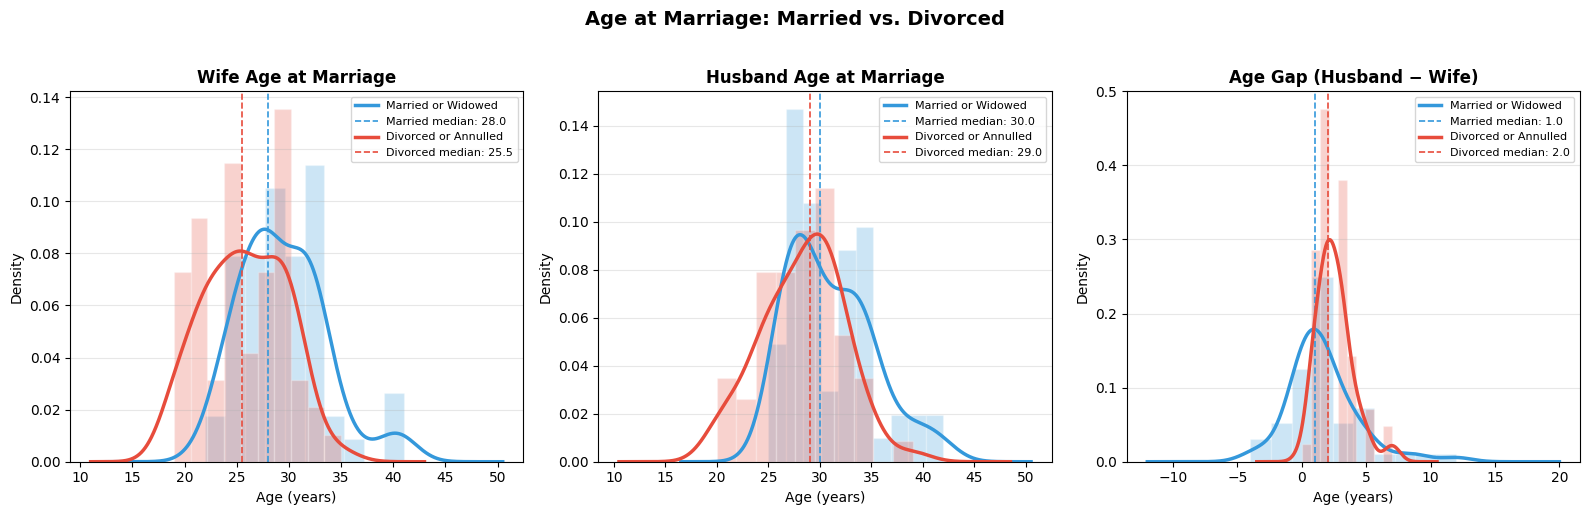

In [15]:
# ── Age Distributions & Stats: Married vs. Divorced ──────────────────────────
status_col = 'What is your current marital status?'

married  = divorced[divorced[status_col] == 'Married or Widowed']
divorced_ = divorced[divorced[status_col] == 'Divorced or Annulled']

# ── Descriptive Statistics by Group ─────────────────────────────────────────
cols = [wife_age, husband_age, 'age_gap']
labels = ['Wife Age', 'Husband Age', 'Age Gap (H−W)']

print("── Married or Widowed ───────────────────────────────────────────────────")
stats_m = married[cols].describe().T.rename(columns={'50%': 'Median'})
stats_m.index = labels
print(stats_m[['count', 'mean', 'std', 'min', '25%', 'Median', '75%', 'max']].round(2).to_string())

print("\n── Divorced or Annulled ─────────────────────────────────────────────────")
stats_d = divorced_[cols].describe().T.rename(columns={'50%': 'Median'})
stats_d.index = labels
print(stats_d[['count', 'mean', 'std', 'min', '25%', 'Median', '75%', 'max']].round(2).to_string())

# ── Overlapping Distribution Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_cols  = [wife_age, husband_age, 'age_gap']
plot_titles = ['Wife Age at Marriage', 'Husband Age at Marriage', 'Age Gap (Husband − Wife)']

groups = [
    (married,   'Married or Widowed',  '#3498db'),
    (divorced_, 'Divorced or Annulled', '#e74c3c'),
]

for ax, col, title in zip(axes, plot_cols, plot_titles):
    for df, label, color in groups:
        data = df[col]
        ax.hist(data, bins=10, color=color, alpha=0.25, edgecolor='white', density=True)
        data.plot.kde(ax=ax, color=color, linewidth=2.5, label=label)
        ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.2,
                   label=f'{label.split()[0]} median: {data.median():.1f}')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Age at Marriage: Married vs. Divorced', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.3 Family background and prior-marriage context
Next, we compare parental background and prior-marriage history across marital-status groups.


── Our Family Backgrounds: ──

Overall count:
Our Family Backgrounds:
Both our parents are Married                          81
One set of parents are Married, the other Divorced    27
Both our parents are Divorced                         12

Count by group:
Our Family Backgrounds:               Both our parents are Divorced  Both our parents are Married  One set of parents are Married, the other Divorced
What is your current marital status?                                                                                                                 
Married or Widowed                                                2                            54                                                   4
Divorced or Annulled                                             10                            27                                                  23

% within group:
Our Family Backgrounds:               Both our parents are Divorced  Both our parents are Married  One set of parents are Ma

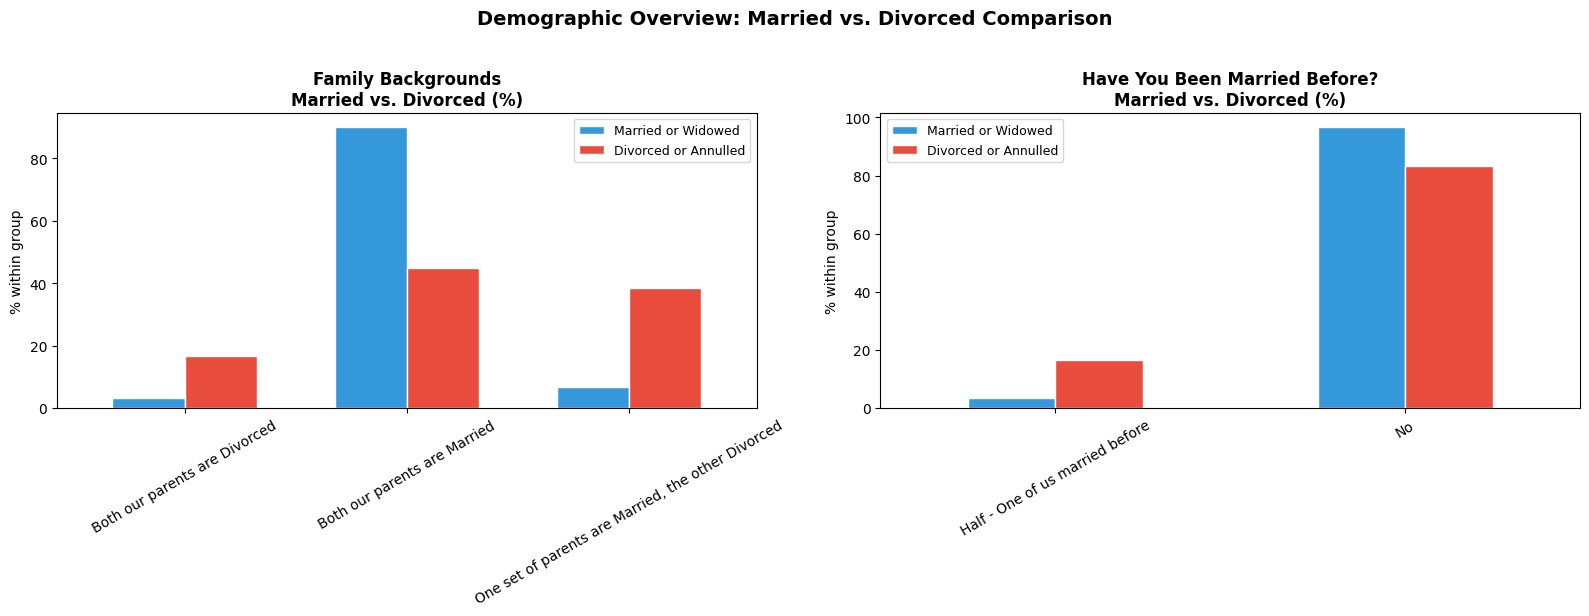

In [16]:
family_col  = 'Our Family Backgrounds:'
married_col = 'Have you been married before?'

status_col = 'What is your current marital status?'
status_order = ['Married or Widowed', 'Divorced or Annulled']

def count_and_pct(col):
    overall = divorced[col].value_counts().rename('Overall')
    by_status = (
        divorced.groupby([status_col, col])
        .size()
        .unstack(fill_value=0)
        .reindex(status_order)
    )
    pct = by_status.div(by_status.sum(axis=1), axis=0) * 100

    print(f"\n── {col} ──")
    print("\nOverall count:")
    print(overall.to_string())
    print("\nCount by group:")
    print(by_status.to_string())
    print("\n% within group:")
    print(pct.round(1).to_string())
    return by_status, pct

fb_counts, fb_pct = count_and_pct(family_col)
mb_counts, mb_pct = count_and_pct(married_col)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db', '#e74c3c']
status_labels = ['Married or Widowed', 'Divorced or Annulled']

# ── Family Backgrounds ────────────────────────────────────────────────────────
fb_pct.T.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.65)
axes[0].set_title('Family Backgrounds\nMarried vs. Divorced (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% within group')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(status_labels, fontsize=9)

# ── Married Before ────────────────────────────────────────────────────────────
mb_pct.T.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Have You Been Married Before?\nMarried vs. Divorced (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% within group')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(status_labels, fontsize=9)

plt.suptitle('Demographic Overview: Married vs. Divorced Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2) Pre-Marital Origins
This section studies early relationship and pre-marriage conditions.

Questions covered:
- Whether housing transition influenced marriage timing
- Relationship length before marriage
- Premarital counselling
- Cohabitation before marriage
- Views on marriage before the wedding

In [17]:
# Show raw values of the columns to analyse

cols_to_analyse = {
    'home'        : 'Was buying a home or moving out a significant factor for marriage?',
    'rel_length'  : 'How long was your relationship before marriage?',
    'counselling' : 'Did you attend Premarital Counselling?',
    'lived_tog'   : 'Did you live together before marriage?',
    'views_marr'  : 'What were your views on marriage prior to the wedding?',
}

status_col   = 'What is your current marital status?'
status_order = ['Married or Widowed', 'Divorced or Annulled']

for key, col in cols_to_analyse.items():
    print(f"\n── {col}")
    print(divorced[col].value_counts().to_string())


── Was buying a home or moving out a significant factor for marriage?
Was buying a home or moving out a significant factor for marriage?
No     70
Yes    50

── How long was your relationship before marriage?
How long was your relationship before marriage?
4+ years             45
2â4 years          26
1â2 years          21
6 monthsâ1 year    14
<6 months            14

── Did you attend Premarital Counselling?
Did you attend Premarital Counselling?
No     95
Yes    25

── Did you live together before marriage?
Did you live together before marriage?
No     80
Yes    40

── What were your views on marriage prior to the wedding?
What were your views on marriage prior to the wedding?
Both wanted marriage                              82
Half - One was ambivalent, one wanted marriage    28
Ambivalent                                        10


In [18]:
# Chi-squared test results

results = []

for key, col in cols_to_analyse.items():
    ct = pd.crosstab(divorced[status_col], divorced[col])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    # Flag low expected counts (rule: < 5 in any cell → chi2 may be unreliable)
    low_expected = (expected < 5).any()
    
    results.append({
        'Column'          : col,
        'Chi2 Statistic'  : round(chi2, 3),
        'p-value'         : round(p, 4),
        'Degrees of Freedom': dof,
        'Significant (p<0.05)': '✅ Yes' if p < 0.05 else '❌ No',
        '⚠️ Low Expected Counts': '⚠️ Yes' if low_expected else 'No',
    })

results_df = pd.DataFrame(results).set_index('Column')
print(results_df.to_string())
results_df

                                                                    Chi2 Statistic  p-value  Degrees of Freedom Significant (p<0.05) ⚠️ Low Expected Counts
Column                                                                                                                                                     
Was buying a home or moving out a significant factor for marriage?           0.309   0.5786                   1                 ❌ No                     No
How long was your relationship before marriage?                             12.589   0.0135                   4                ✅ Yes                     No
Did you attend Premarital Counselling?                                       3.234   0.0721                   1                 ❌ No                     No
Did you live together before marriage?                                       0.938   0.3329                   1                 ❌ No                     No
What were your views on marriage prior to the wedding?          

,Chi2 Statistic,p-value,Degrees of Freedom,Significant (p<0.05),⚠️ Low Expected Counts
Column,,,,,
Was buying a home or moving out a significant factor for marriage?,0.309,0.5786,1,❌ No,No
How long was your relationship before marriage?,12.589,0.0135,4,✅ Yes,No
Did you attend Premarital Counselling?,3.234,0.0721,1,❌ No,No
Did you live together before marriage?,0.938,0.3329,1,❌ No,No
What were your views on marriage prior to the wedding?,12.265,0.0022,2,✅ Yes,No


In [19]:
# Percentage differences 

for key, col in cols_to_analyse.items():
    by_status = (
        divorced.groupby([status_col, col])
        .size()
        .unstack(fill_value=0)
        .reindex(status_order)
    )
    pct = by_status.div(by_status.sum(axis=1), axis=0) * 100

    print(f"\n{'─'*70}")
    print(f"  {col}")
    print(f"{'─'*70}")
    print("\n  Count:")
    print(by_status.to_string())
    print("\n  % within group:")
    print(pct.round(1).to_string())


──────────────────────────────────────────────────────────────────────
  Was buying a home or moving out a significant factor for marriage?
──────────────────────────────────────────────────────────────────────

  Count:
Was buying a home or moving out a significant factor for marriage?  No  Yes
What is your current marital status?                                       
Married or Widowed                                                  33   27
Divorced or Annulled                                                37   23

  % within group:
Was buying a home or moving out a significant factor for marriage?    No   Yes
What is your current marital status?                                          
Married or Widowed                                                  55.0  45.0
Divorced or Annulled                                                61.7  38.3

──────────────────────────────────────────────────────────────────────
  How long was your relationship before marriage?
─────────────────

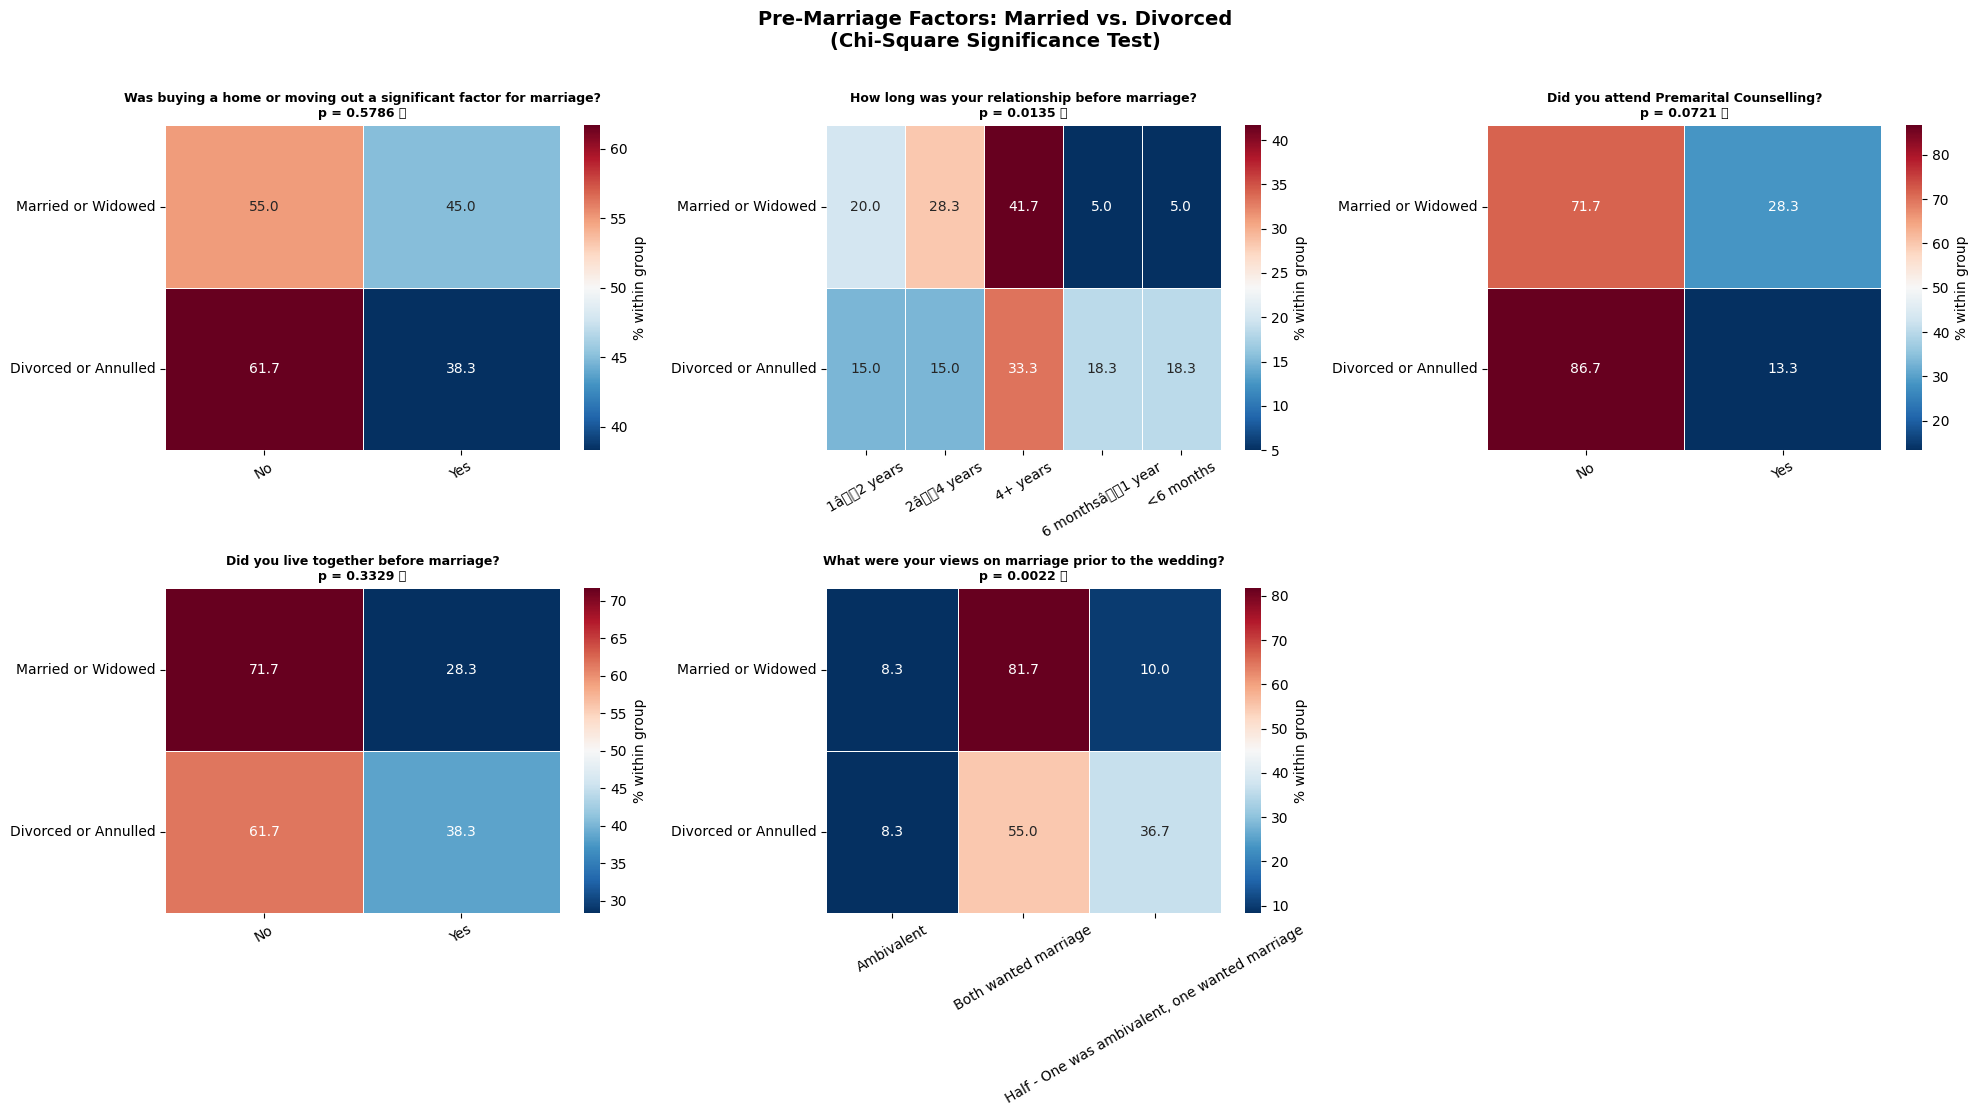

In [20]:
# Visualise with a heatmap

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for ax, (key, col) in zip(axes, cols_to_analyse.items()):
    ct = (
        divorced.groupby([status_col, col])
        .size()
        .unstack(fill_value=0)
        .reindex(status_order)
    )
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    _, p, _, _ = chi2_contingency(ct)
    sig_label = f'p = {p:.4f} {"✅" if p < 0.05 else "❌"}'

    sns.heatmap(
        pct, ax=ax, annot=True, fmt='.1f', cmap='RdBu_r',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': '% within group'}
    )

    ax.set_title(f'{col}\n{sig_label}', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

axes[-1].set_visible(False)

plt.suptitle('Pre-Marriage Factors: Married vs. Divorced\n(Chi-Square Significance Test)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.1 Pre-marital origins: key takeaway
Among tested variables, **pre-marriage views on marriage** and **relationship length** show the clearest statistical separation between married and divorced groups in this sample.

### 2.2 Free-text standardisation: "How did you meet?"
Because this question includes free-text responses, we want to normalise raw entries into consistent categories before statistical comparison (where it makes sense).

In [21]:
meet_col = 'How did you meet?'

print(f"Unique responses: {divorced[meet_col].nunique()}")
print()
for val in sorted(divorced[meet_col].dropna().unique()):
    print(f"  {repr(val)}")

Unique responses: 15

  'At an event'
  'Cc events '
  'Club'
  'Clubbing'
  'Distance relative'
  'Family introduction'
  'Met in USA'
  'Mutual friends'
  'On a plane'
  'Online (e.g. Dating App)'
  'Religious Place of Worship'
  'School'
  'Social gathering by chance'
  'Workplace'
  'only my wife and I know how we met.  Not something we have shared.'


In [22]:
meet_mapping = {
    # ── Standard options ──────────────────────────────────────────────────────
    'School'                    : 'School',
    'Workplace'                 : 'Workplace',
    'Mutual friends'            : 'Mutual Friends',
    'Online (e.g. Dating App)'  : 'Dating App / Online',
    'Religious Place of Worship': 'Religious Community',
    'Family introduction'       : 'Family Introduction',

    # ── Free-text "Other" responses ───────────────────────────────────────────
    'At an event'               : 'Social / Event',
    'Cc events '                : 'Social / Event',
    'Club'                      : 'Social / Event',
    'Clubbing'                  : 'Social / Event',
    'Social gathering by chance': 'Social / Event',
    'Distance relative'         : 'Family Introduction',
    'Met in USA'                : 'Other',
    'On a plane'                : 'Other',
    'only my wife and I know how we met.  Not something we have shared.' : 'Other',
}

divorced['meet_clean'] = divorced[meet_col].map(meet_mapping)

unmapped = divorced[divorced['meet_clean'].isna() & divorced[meet_col].notna()]
if unmapped.empty:
    print("✅ All responses mapped successfully.")
    print(divorced['meet_clean'].value_counts().to_string())
else:
    print(f"⚠️  Unmapped responses ({len(unmapped)} rows):")
    print(unmapped[meet_col].to_string())

✅ All responses mapped successfully.
meet_clean
Workplace              28
School                 25
Mutual Friends         21
Dating App / Online    17
Social / Event         10
Family Introduction     9
Religious Community     7
Other                   3


In [23]:
status_col = 'What is your current marital status?'

meet_by_status = (
    divorced.groupby([status_col, 'meet_clean'])
    .size()
    .unstack(fill_value=0)
    .reindex(['Married or Widowed', 'Divorced or Annulled'])  # force correct order
)

meet_pct = meet_by_status.div(meet_by_status.sum(axis=1), axis=0) * 100

print("── Count ────────────────────────────────────────────────────────────────")
print(meet_by_status.to_string())
print("\n── % within group ───────────────────────────────────────────────────────")
print(meet_pct.round(1).to_string())

── Count ────────────────────────────────────────────────────────────────
meet_clean                            Dating App / Online  Family Introduction  Mutual Friends  Other  Religious Community  School  Social / Event  Workplace
What is your current marital status?                                                                                                                         
Married or Widowed                                      8                    2              10      3                    4      15               5         13
Divorced or Annulled                                    9                    7              11      0                    3      10               5         15

── % within group ───────────────────────────────────────────────────────
meet_clean                            Dating App / Online  Family Introduction  Mutual Friends  Other  Religious Community  School  Social / Event  Workplace
What is your current marital status?                         

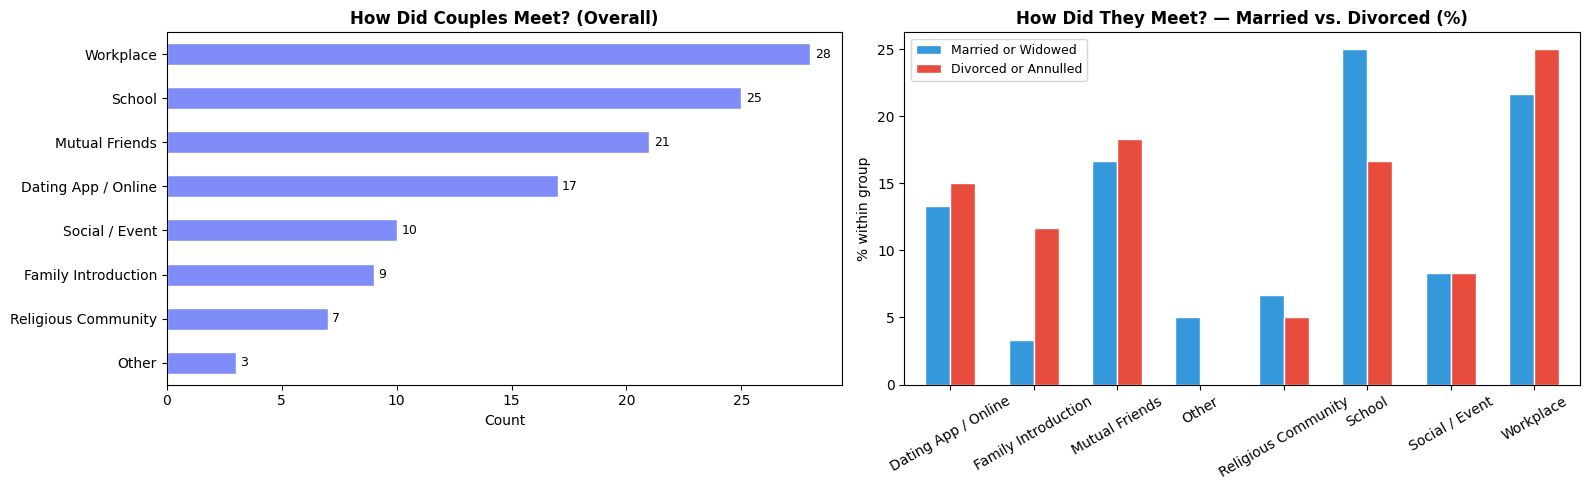

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overall count bar chart
overall = meet_by_status.sum(axis=0)
overall.sort_values().plot(kind='barh', ax=axes[0], color='#7f8cf7', edgecolor='white')
axes[0].set_title('How Did Couples Meet? (Overall)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va='center', fontsize=9)

# Right: grouped % stacked bar chart
meet_pct.T.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'],
                edgecolor='white', width=0.6)
axes[1].set_title('How Did They Meet? — Married vs. Divorced (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% within group')
axes[1].legend(['Married or Widowed', 'Divorced or Annulled'], fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [25]:
ct = pd.crosstab(divorced[status_col], divorced['meet_clean'])

chi2, p, dof, expected = chi2_contingency(ct)

# Cramér's V (effect size)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi-Square Statistic : {chi2:.3f}")
print(f"p-value              : {p:.4f}  {'✅ Significant' if p < 0.05 else '❌ Not significant'} at α = 0.05")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramér's V           : {cramers_v:.3f}  ", end='')
if   cramers_v >= 0.5: print("(Strong effect)")
elif cramers_v >= 0.3: print("(Moderate effect)")
elif cramers_v >= 0.1: print("(Weak effect)")
else:                  print("(Negligible effect)")

low_expected = (expected < 5).any()
if low_expected:
    print("\n⚠️  Some expected cell counts < 5 — interpret chi-square with caution.")
    print("   Consider merging smaller categories (e.g. 'Other') if needed.")

Chi-Square Statistic : 7.170
p-value              : 0.4114  ❌ Not significant at α = 0.05
Degrees of Freedom   : 7
Cramér's V           : 0.244  (Weak effect)

⚠️  Some expected cell counts < 5 — interpret chi-square with caution.
   Consider merging smaller categories (e.g. 'Other') if needed.


In [26]:
# Standardised residuals: values > +2 or < -2 are noteworthy
observed  = ct.values
std_resid = (observed - expected) / np.sqrt(expected)

std_resid_df = pd.DataFrame(
    std_resid,
    index=ct.index,
    columns=ct.columns
)

print("── Standardised Residuals ───────────────────────────────────────────────")
print("   Values > +2.0 → over-represented in that group")
print("   Values < -2.0 → under-represented in that group")
print()
print(std_resid_df.round(2).to_string())

# Flag noteworthy cells
print("\n── Noteworthy cells (|residual| > 1.5) ─────────────────────────────────")
for row in ct.index:
    for col in ct.columns:
        r = std_resid_df.loc[row, col]
        if abs(r) > 1.5:
            direction = 'over' if r > 0 else 'under'
            print(f"  {row:25s} | {col:25s} : {r:+.2f}  ({direction}-represented)")

── Standardised Residuals ───────────────────────────────────────────────
   Values > +2.0 → over-represented in that group
   Values < -2.0 → under-represented in that group

meet_clean                            Dating App / Online  Family Introduction  Mutual Friends  Other  Religious Community  School  Social / Event  Workplace
What is your current marital status?                                                                                                                         
Divorced or Annulled                                 0.17                 1.18            0.15  -1.22                -0.27   -0.71             0.0       0.27
Married or Widowed                                  -0.17                -1.18           -0.15   1.22                 0.27    0.71             0.0      -0.27

── Noteworthy cells (|residual| > 1.5) ─────────────────────────────────


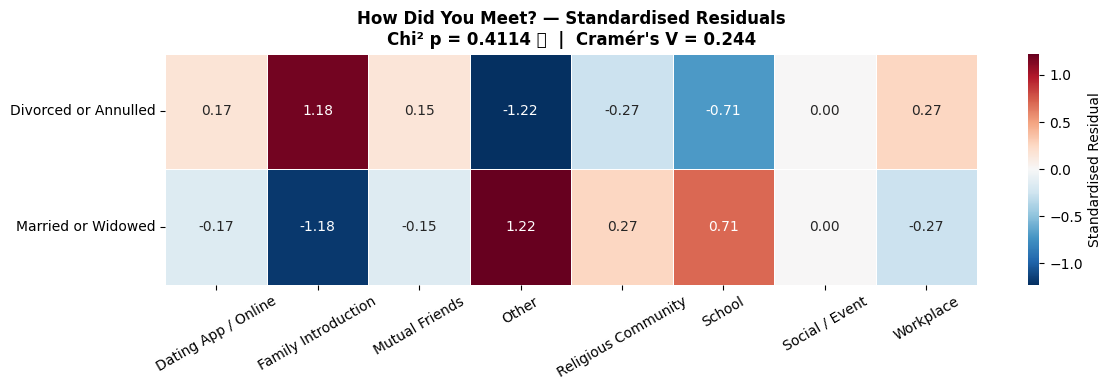

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    std_resid_df, ax=ax,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Standardised Residual'}
)

ax.set_title(
    f'How Did You Meet? — Standardised Residuals\n'
    f'Chi² p = {p:.4f} {"✅" if p < 0.05 else "❌"}  |  Cramér\'s V = {cramers_v:.3f}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### 2.3 Meeting-context takeaway
After category harmonisation, meeting context shows limited association with marital outcome relative to stronger predictors elsewhere in the survey.

## 3) Beliefs, Family Planning, and Financial Alignment
This section evaluates beliefs- and values-oriented factors against marital outcome.

Variables covered:
- Belief in soulmates
- Religious alignment
- Views on children and actual children status
- Political alignment
- Household income structure
- Financial management alignment

In [28]:
beliefs_cols = {
    'soulmates'  : 'Do you believe in "Soulmates" or "The One"?',
    'religion'   : 'Our views on religion:',
    'children'   : 'Do you have children together?',
    'views_child': 'What were your views on children?',
    'politics'   : 'On political views:',
    'household_income'  : 'Our household is primarily:',
    'finances'   : 'On managing household finances:',
}

status_col   = 'What is your current marital status?'
status_order = ['Married or Widowed', 'Divorced or Annulled']

for key, col in beliefs_cols.items():
    print(f"\n── {col}")
    print(divorced[col].value_counts().to_string())


── Do you believe in "Soulmates" or "The One"?
Do you believe in "Soulmates" or "The One"?
Half - one of us does    47
No - we don't            42
Yes - we both do         31

── Our views on religion:
Our views on religion:
Same beliefs and practices              45
Different beliefs but accepting         42
Same beliefs but different practices    19
Different beliefs altogether            14

── Do you have children together?
Do you have children together?
Yes    83
No     37

── What were your views on children?
What were your views on children?
Both wanted children                  61
Mixed - One spouse wanted children    21
Both ambivalent or undecided          16
Both didn't want children             14
Too old                                8

── On political views:
On political views:
We have different views but respect them    45
We both avoid discussing politics           33
We share the same views                     31
Our different views cause conflict          11

── Our

In [29]:
# Treat "Too Old" as "Both didn't want children".

views_child_col = beliefs_cols['views_child']

views_child_mapping = {
    'Both wanted children'               : 'Both wanted children',
    "Both didn't want children"          : "Both didn't want children",
    'Mixed - One spouse wanted children' : 'Mixed views',
    'Both ambivalent or undecided'       : 'Both ambivalent or undecided',
    'Too old'                            : "Both didn't want children",  # Option A
}

divorced[views_child_col] = divorced[views_child_col].map(views_child_mapping)

print(divorced[views_child_col].value_counts().to_string())

What were your views on children?
Both wanted children            61
Both didn't want children       22
Mixed views                     21
Both ambivalent or undecided    16


In [43]:
status_col = 'What is your current marital status?'
status_order = ['Married or Widowed', 'Divorced or Annulled']

for key, col in beliefs_cols.items():
    ct = pd.crosstab(divorced[status_col], divorced[col]).reindex(status_order)
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
    combined = pd.concat({'Count': ct, 'Percent (%)': pct}, axis=1)

    print(f"\n── {col}")
    display(combined)



── Do you believe in "Soulmates" or "The One"?


Count  \
Do you believe in "Soulmates" or "The One"? Half - one of us does   
What is your current marital status?                                
Married or Widowed                                             16   
Divorced or Annulled                                           31   

                                                                            \
Do you believe in "Soulmates" or "The One"? No - we don't Yes - we both do   
What is your current marital status?                                         
Married or Widowed                                     20               24   
Divorced or Annulled                                   22                7   

                                                      Percent (%)  \
Do you believe in "Soulmates" or "The One"? Half - one of us does   
What is your current marital status?                                
Married or Widowed                                           26.7   
Divorced or Annulled                                         51.7   

                                                                            
Do you believe in "Soulmates" or "The One"? No - we don't Yes - we both do  
What is your current marital status?                                        
Married or Widowed                                   33.3             40.0  
Divorced or Annulled                                 36.7             11.7


── Our views on religion:


Count  \
Our views on religion:               Different beliefs altogether   
What is your current marital status?                                
Married or Widowed                                              3   
Divorced or Annulled                                           11   

                                                                      \
Our views on religion:               Different beliefs but accepting   
What is your current marital status?                                   
Married or Widowed                                                23   
Divorced or Annulled                                              19   

                                                                 \
Our views on religion:               Same beliefs and practices   
What is your current marital status?                              
Married or Widowed                                           28   
Divorced or Annulled                                         17   

                                                                           \
Our views on religion:               Same beliefs but different practices   
What is your current marital status?                                        
Married or Widowed                                                      6   
Divorced or Annulled                                                   13   

                                                      Percent (%)  \
Our views on religion:               Different beliefs altogether   
What is your current marital status?                                
Married or Widowed                                            5.0   
Divorced or Annulled                                         18.3   

                                                                      \
Our views on religion:               Different beliefs but accepting   
What is your current marital status?                                   
Married or Widowed                                              38.3   
Divorced or Annulled                                            31.7   

                                                                 \
Our views on religion:               Same beliefs and practices   
What is your current marital status?                              
Married or Widowed                                         46.7   
Divorced or Annulled                                       28.3   

                                                                           
Our views on religion:               Same beliefs but different practices  
What is your current marital status?                                       
Married or Widowed                                                   10.0  
Divorced or Annulled                                                 21.7


── Do you have children together?


...

Count  \
On political views:                  Our different views cause conflict   
What is your current marital status?                                      
Married or Widowed                                                    2   
Divorced or Annulled                                                  9   

                                                                        \
On political views:                  We both avoid discussing politics   
What is your current marital status?                                     
Married or Widowed                                                   6   
Divorced or Annulled                                                27   

                                                                               \
On political views:                  We have different views but respect them   
What is your current marital status?                                            
Married or Widowed                                                         27   
Divorced or Annulled                                                       18   

                                                              \
On political views:                  We share the same views   
What is your current marital status?                           
Married or Widowed                                        25   
Divorced or Annulled                                       6   

                                                            Percent (%)  \
On political views:                  Our different views cause conflict   
What is your current marital status?                                      
Married or Widowed                                                  3.3   
Divorced or Annulled                                               15.0   

                                                                        \
On political views:                  We both avoid discussing politics   
What is your current marital status?                                     
Married or Widowed                                                10.0   
Divorced or Annulled                                              45.0   

                                                                               \
On political views:                  We have different views but respect them   
What is your current marital status?                                            
Married or Widowed                                                       45.0   
Divorced or Annulled                                                     30.0   

                                                              
On political views:                  We share the same views  
What is your current marital status?                          
Married or Widowed                                      41.7  
Divorced or Annulled                                    10.0


── Our household is primarily:


Count              \
Our household is primarily:          Both unemployed Dual income   
What is your current marital status?                               
Married or Widowed                                 0          44   
Divorced or Annulled                               6          24   

                                                       Percent (%)  \
Our household is primarily:          Single income Both unemployed   
What is your current marital status?                                 
Married or Widowed                              16             0.0   
Divorced or Annulled                            30            10.0   

                                                                
Our household is primarily:          Dual income Single income  
What is your current marital status?                            
Married or Widowed                          73.3          26.7  
Divorced or Annulled                        40.0          50.0


── On managing household finances:


Count  \
On managing household finances:      Half aligned, half in disagreement   
What is your current marital status?                                      
Married or Widowed                                                   11   
Divorced or Annulled                                                 31   

                                                                    \
On managing household finances:      Mostly aligned Rarely aligned   
What is your current marital status?                                 
Married or Widowed                               48              1   
Divorced or Annulled                              7             22   

                                                            Percent (%)  \
On managing household finances:      Half aligned, half in disagreement   
What is your current marital status?                                      
Married or Widowed                                                 18.3   
Divorced or Annulled                                               51.7   

                                                                    
On managing household finances:      Mostly aligned Rarely aligned  
What is your current marital status?                                
Married or Widowed                             80.0            1.7  
Divorced or Annulled                           11.7           36.7

In [31]:
def cramers_v(chi2, n, k):
    return np.sqrt(chi2 / (n * (k - 1)))

def effect_label(v):
    if   v >= 0.5: return 'Strong'
    elif v >= 0.3: return 'Moderate'
    elif v >= 0.1: return 'Weak'
    else:          return 'Negligible'

results = []
for key, col in beliefs_cols.items():
    ct = pd.crosstab(divorced[status_col], divorced[col])
    chi2, p, dof, expected = chi2_contingency(ct)
    n  = ct.values.sum()
    cv = cramers_v(chi2, n, min(ct.shape))
    low_exp = (expected < 5).any()

    results.append({
        'Column'              : col,
        'Chi2'                : round(chi2, 3),
        'p-value'             : round(p, 4),
        'Significant (p<0.05)': '✅' if p < 0.05 else '❌',
        "Cramér's V"          : round(cv, 3),
        'Effect Size'         : effect_label(cv),
        '⚠️ Low Exp. Counts'  : '⚠️' if low_exp else '',
    })

results_df = pd.DataFrame(results).set_index('Column')
print(results_df.to_string())
results_df

                                               Chi2  p-value Significant (p<0.05)  Cramér's V Effect Size ⚠️ Low Exp. Counts
Column                                                                                                                      
Do you believe in "Soulmates" or "The One"?  14.205   0.0008                    ✅       0.344    Moderate                   
Our views on religion:                       10.220   0.0168                    ✅       0.292        Weak                   
Do you have children together?                0.625   0.4291                    ❌       0.072  Negligible                   
What were your views on children?            21.449   0.0001                    ✅       0.423    Moderate                   
On political views:                          31.263   0.0000                    ✅       0.510      Strong                   
Our household is primarily:                  16.143   0.0003                    ✅       0.367    Moderate                 ⚠️


,Chi2,p-value,Significant (p<0.05),Cramér's V,Effect Size,⚠️ Low Exp. Counts
Column,,,,,,
"Do you believe in ""Soulmates"" or ""The One""?",14.205,0.0008,✅,0.344,Moderate,
Our views on religion:,10.220,0.0168,✅,0.292,Weak,
Do you have children together?,0.625,0.4291,❌,0.072,Negligible,
What were your views on children?,21.449,0.0001,✅,0.423,Moderate,
On political views:,31.263,0.0000,✅,0.510,Strong,
Our household is primarily:,16.143,0.0003,✅,0.367,Moderate,⚠️
On managing household finances:,59.261,0.0000,✅,0.703,Strong,


In [32]:
print("Standardised Residuals  (> +1.5 = over-represented | < -1.5 = under-represented)\n")

for key, col in beliefs_cols.items():
    ct       = pd.crosstab(divorced[status_col], divorced[col])
    _, _, _, expected = chi2_contingency(ct)
    std_resid = (ct.values - expected) / np.sqrt(expected)
    sr_df     = pd.DataFrame(std_resid, index=ct.index, columns=ct.columns)

    noteworthy = [(r, c, sr_df.loc[r, c])
                  for r in ct.index for c in ct.columns
                  if abs(sr_df.loc[r, c]) > 1.5]

    print(f"── {col}")
    if noteworthy:
        for row, cat, val in sorted(noteworthy, key=lambda x: abs(x[2]), reverse=True):
            direction = 'over' if val > 0 else 'under'
            print(f"   {row:25s} | {cat:40s} : {val:+.2f}  ({direction}-represented)")
    else:
        print("   No categories with notable residuals (all within ±1.5)")
    print()

Standardised Residuals  (> +1.5 = over-represented | < -1.5 = under-represented)

── Do you believe in "Soulmates" or "The One"?
   Divorced or Annulled      | Yes - we both do                         : -2.16  (under-represented)
   Married or Widowed        | Yes - we both do                         : +2.16  (over-represented)
   Divorced or Annulled      | Half - one of us does                    : +1.55  (over-represented)
   Married or Widowed        | Half - one of us does                    : -1.55  (under-represented)

── Our views on religion:
   Divorced or Annulled      | Different beliefs altogether             : +1.51  (over-represented)
   Married or Widowed        | Different beliefs altogether             : -1.51  (under-represented)

── Do you have children together?
   No categories with notable residuals (all within ±1.5)

── What were your views on children?
   Divorced or Annulled      | Both didn't want children                : +2.41  (over-represented)
   Married

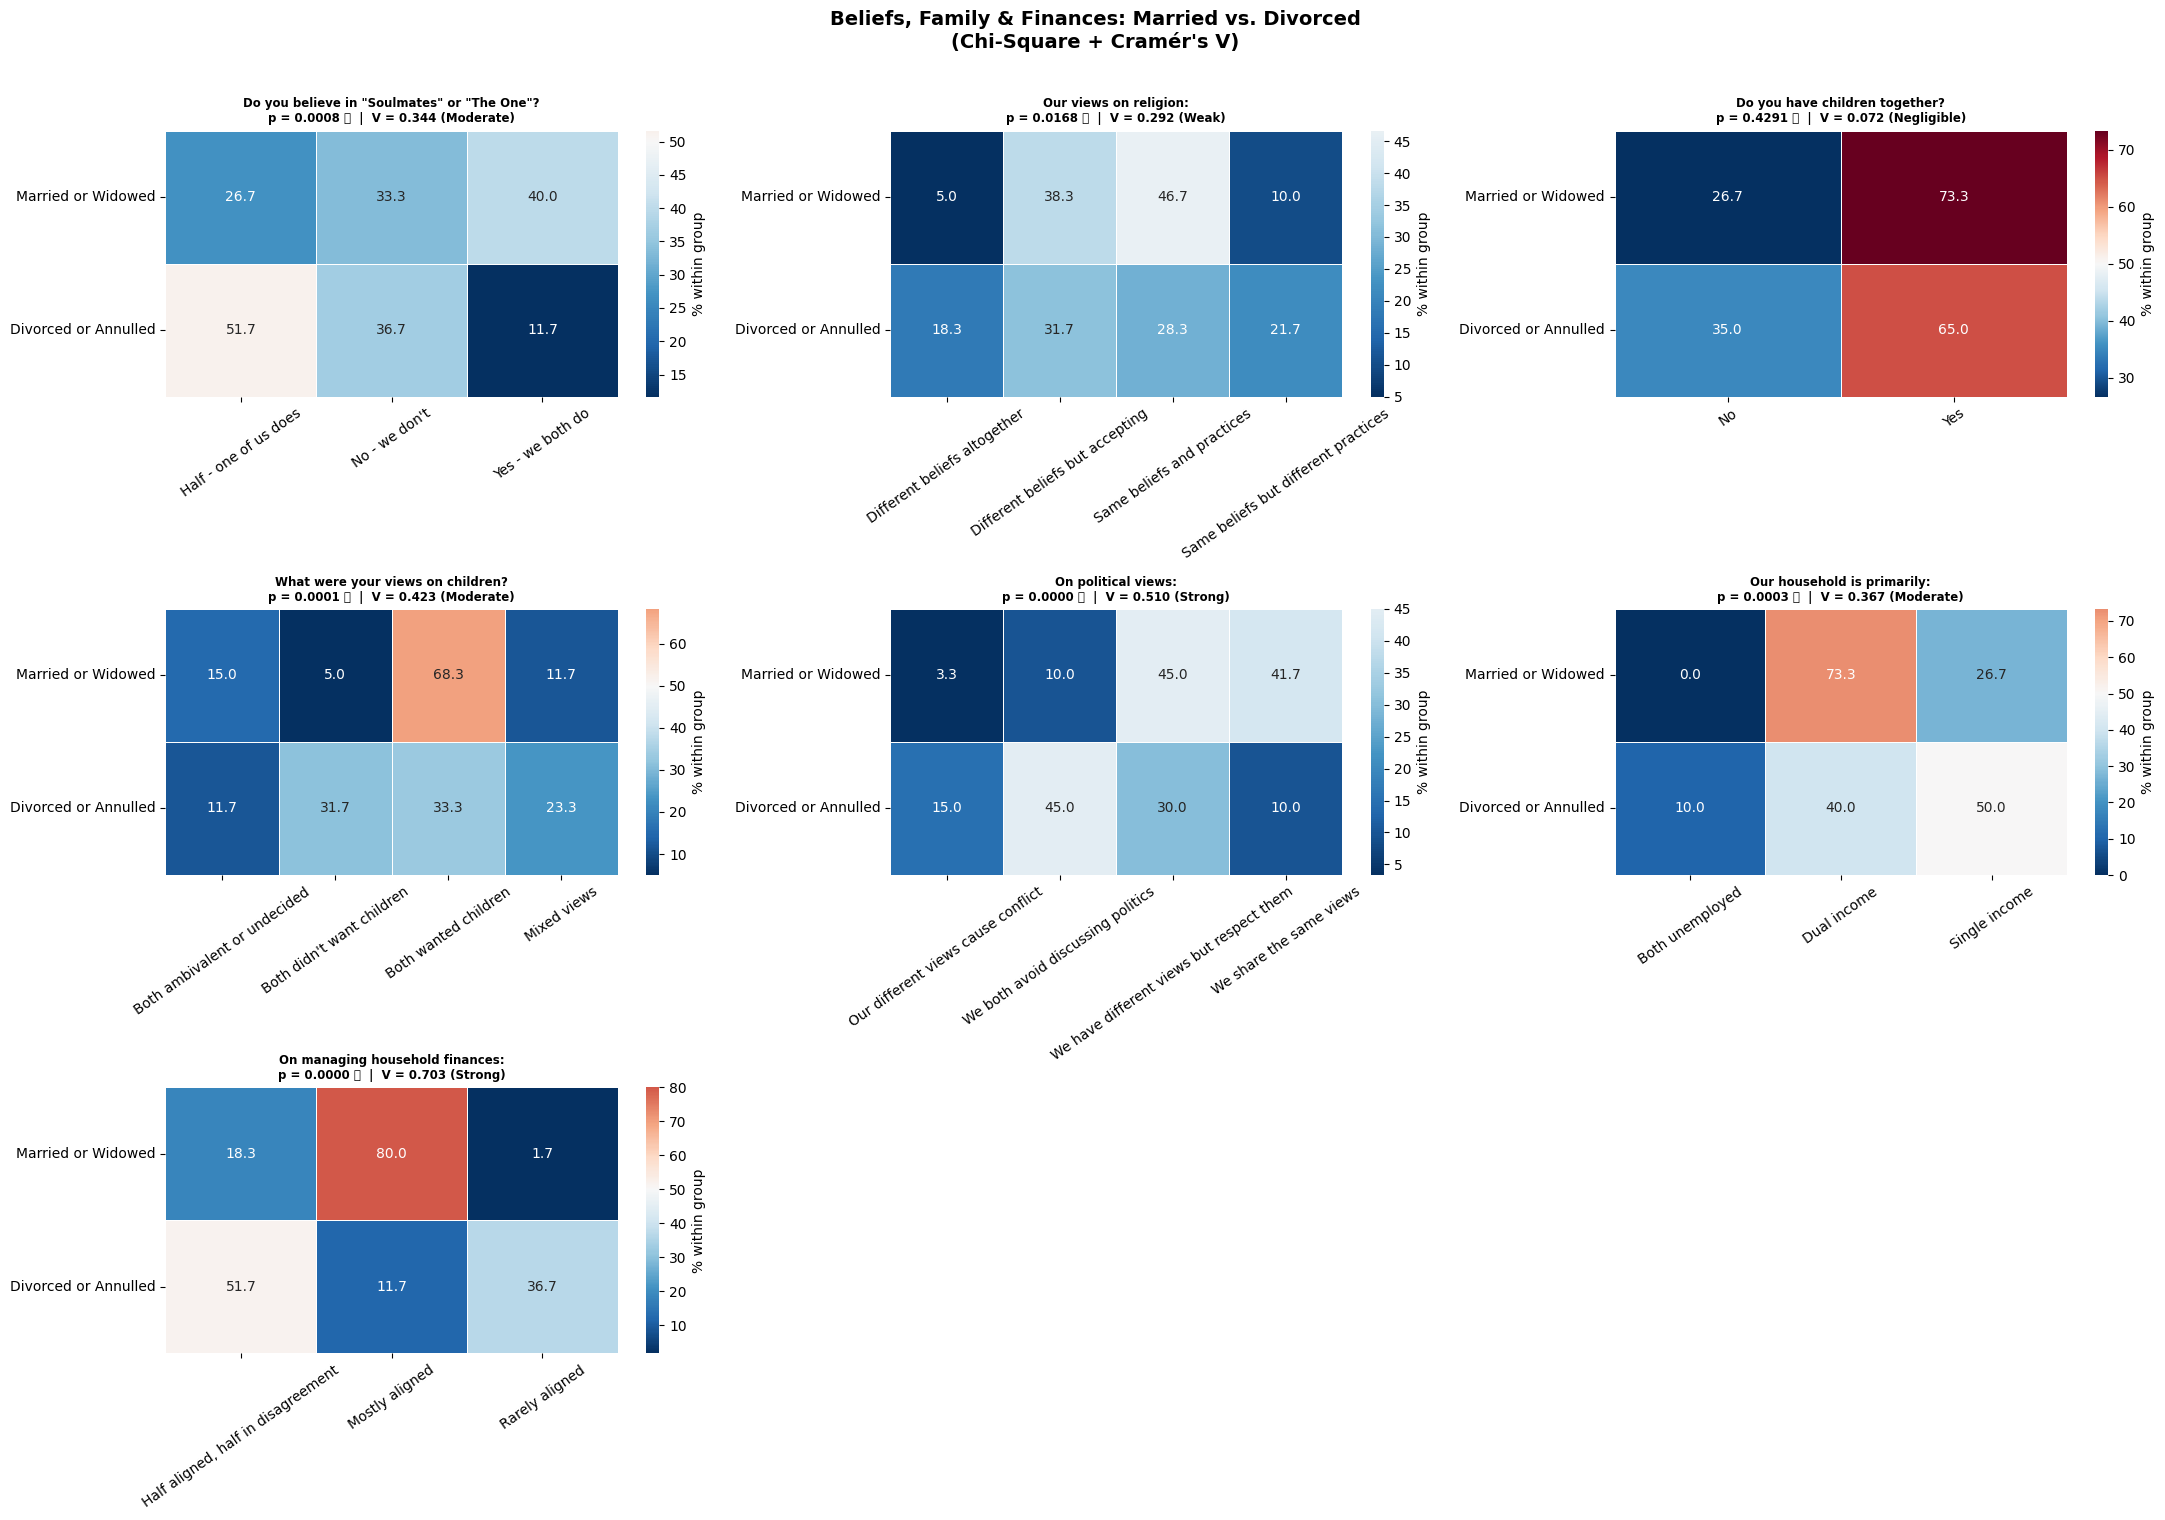

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(22, 15))
axes = axes.flatten()

for i, (key, col) in enumerate(beliefs_cols.items()):
    ax = axes[i]
    ct = pd.crosstab(divorced[status_col], divorced[col]).reindex(status_order)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    chi2, p, dof, expected = chi2_contingency(ct)
    n  = ct.values.sum()
    cv = cramers_v(chi2, n, min(ct.shape))

    sns.heatmap(
        pct, ax=ax,
        annot=True, fmt='.1f',
        cmap='RdBu_r', center=50,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': '% within group'}
    )
    ax.set_title(
        f'{col}\np = {p:.4f} {"✅" if p < 0.05 else "❌"}  |  V = {cv:.3f} ({effect_label(cv)})',
        fontsize=8.5, fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

# Hide unused subplots
for j in range(len(beliefs_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Beliefs, Family & Finances: Married vs. Divorced\n(Chi-Square + Cramér\'s V)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.1 Beliefs and finances: summary
In this dataset, the strongest associations are observed for:
- Managing household finances
- Political views

Moderate associations are observed for:
- Views on children
- Household income structure
- Belief in soulmates

## 4) In-Laws Analysis: Individual vs Engineered Features

### Objective
Assess whether in-law relationship quality is associated with:
1. Current marital status
2. Relationship length before marriage
3. Whether the couple has children

### Feature families
**Individual features**
- respondent in-law relationship
- spouse/ex in-law relationship

**Engineered features**
- joint pairing category
- mean-band, minimum-band, and mismatch-band features
- compact pair profile

### Method
- Chi-square tests for association
- Cramér’s V for effect size
- low expected-count flag for sparse tables
- Spearman checks for ordinal trend with relationship length / children

### How to read results
- Prioritise features with higher Cramér’s V and robust p-values
- Treat sparse-cell warnings as exploratory
- Use diagnostics to identify which pairings drive association

In [34]:
# --- Columns ---
status_col = 'What is your current marital status?'
rel_length_col = 'How long was your relationship before marriage?'
children_col = 'Do you have children together?'

inlaw_you_col = 'Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [You and your in-laws]'
inlaw_spouse_col = 'Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [Your spouse/ex and their in-laws]'

# --- Clean + score ---
scale = {'Very Bad': 1, 'Bad': 2, 'Neutral': 3, 'Good': 4, 'Very Good': 5}

for c in [inlaw_you_col, inlaw_spouse_col]:
    divorced[c] = divorced[c].astype(str).str.strip()

divorced['inlaw_you_score'] = divorced[inlaw_you_col].map(scale) # Your relationship with in-laws
divorced['inlaw_spouse_score'] = divorced[inlaw_spouse_col].map(scale) # Your spouse's relationship with in-laws

# --- Engineered combined features ---
divorced['inlaw_mean_score'] = divorced[['inlaw_you_score', 'inlaw_spouse_score']].mean(axis=1) # Average of both
divorced['inlaw_min_score'] = divorced[['inlaw_you_score', 'inlaw_spouse_score']].min(axis=1) # Minimum of both
divorced['inlaw_gap_score'] = (divorced['inlaw_you_score'] - divorced['inlaw_spouse_score']).abs() # Absolute difference

divorced['inlaw_joint_cat'] = divorced[inlaw_you_col] + ' | ' + divorced[inlaw_spouse_col] # Specific pairings (e.g. "Good | Bad")

divorced['inlaw_mean_band'] = pd.cut(
    divorced['inlaw_mean_score'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Neutral', 'High'],
    include_lowest=True
)

divorced['inlaw_min_band'] = pd.cut(
    divorced['inlaw_min_score'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Neutral', 'High'],
    include_lowest=True
)

divorced['inlaw_gap_band'] = pd.cut(
    divorced['inlaw_gap_score'],
    bins=[-0.1, 0.1, 1.1, 5],
    labels=['Aligned (0)', 'Slight mismatch (1)', 'Large mismatch (2+)'],
    include_lowest=True
)

divorced['inlaw_pair_profile'] = np.select(
    [
        (divorced['inlaw_you_score'] >= 4) & (divorced['inlaw_spouse_score'] >= 4),
        (divorced['inlaw_you_score'] <= 2) & (divorced['inlaw_spouse_score'] <= 2),
        (divorced['inlaw_gap_score'] >= 2),
    ],
    ['Both positive', 'Both strained', 'Large mismatch'],
    default='Mixed/neutral'
)

# --- Helper ---
def chi2_assoc(df, feature, target):
    sub = df[[feature, target]].dropna()
    ct = pd.crosstab(sub[target], sub[feature])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return {
            'Feature': feature, 'Target': target, 'Chi2': np.nan, 'p-value': np.nan,
            "Cramér's V": np.nan, 'Significant (p<0.05)': 'N/A', 'Low expected (<5)': 'N/A'
        }
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return {
        'Feature': feature,
        'Target': target,
        'Chi2': round(chi2, 3),
        'p-value': round(p, 4),
        "Cramér's V": round(v, 3),
        'Significant (p<0.05)': '✅' if p < 0.05 else '❌',
        'Low expected (<5)': '⚠️' if (expected < 5).any() else ''
    }

# --- A) In-laws -> marital status: single vs combined ---
features_status = [
    inlaw_you_col,
    inlaw_spouse_col,
    'inlaw_joint_cat',
    'inlaw_mean_band',
    'inlaw_min_band',
    'inlaw_gap_band',
    'inlaw_pair_profile'
]

status_results = pd.DataFrame([chi2_assoc(divorced, f, status_col) for f in features_status]) \
    .sort_values(by=["Cramér's V", 'p-value'], ascending=[False, True])

print("\n=== In-laws vs Marital Status (strongest first) ===")
print(status_results.to_string(index=False))

# --- B) In-laws vs relationship length and children ---
features_secondary = [inlaw_you_col, inlaw_spouse_col, 'inlaw_mean_band', 'inlaw_min_band', 'inlaw_pair_profile']

secondary_results = []
for f in features_secondary:
    secondary_results.append(chi2_assoc(divorced, f, rel_length_col))
    secondary_results.append(chi2_assoc(divorced, f, children_col))

secondary_results = pd.DataFrame(secondary_results) \
    .sort_values(by=['Target', "Cramér's V", 'p-value'], ascending=[True, False, True])

print("\n=== In-laws vs Relationship Length / Children ===")
print(secondary_results.to_string(index=False))

# --- C) Optional ordinal trend checks (numeric in-law mean) ---
def normalize_rel_length(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace('â€“', '–').replace('-', '–')
    mapping = {
        '<6 months': 0,
        '6 months–1 year': 1,
        '1–2 years': 2,
        '2–4 years': 3,
        '4+ years': 4
    }
    return mapping.get(s, np.nan)

divorced['rel_length_ord'] = divorced[rel_length_col].apply(normalize_rel_length)
divorced['children_bin'] = divorced[children_col].map({'No': 0, 'Yes': 1})

tmp1 = divorced[['inlaw_mean_score', 'rel_length_ord']].dropna()
rho1, p1 = spearmanr(tmp1['inlaw_mean_score'], tmp1['rel_length_ord'])

tmp2 = divorced[['inlaw_mean_score', 'children_bin']].dropna()
rho2, p2 = spearmanr(tmp2['inlaw_mean_score'], tmp2['children_bin'])

print("\n=== Spearman (ordinal trend) ===")
print(f"In-law mean score vs relationship length: rho={rho1:.3f}, p={p1:.4f}")
print(f"In-law mean score vs has children      : rho={rho2:.3f}, p={p2:.4f}")


=== In-laws vs Marital Status (strongest first) ===
                                                                                                              Feature                               Target   Chi2  p-value  Cramér's V Significant (p<0.05) Low expected (<5)
                                                                                                      inlaw_joint_cat What is your current marital status? 64.180   0.0000       0.731                    ✅                ⚠️
                                                                                                       inlaw_min_band What is your current marital status? 50.315   0.0000       0.648                    ✅                  
                                                                                                      inlaw_mean_band What is your current marital status? 47.736   0.0000       0.631                    ✅                  
Relationship with In-laws is best described as: (Select Neu

In [35]:
# 1) Show rich tables in notebook
display(status_results)
display(secondary_results)

# 2) Diagnose what drives inlaw_joint_cat chi-square
joint = 'inlaw_joint_cat'
ct = pd.crosstab(divorced[status_col], divorced[joint])

chi2, p, dof, expected = chi2_contingency(ct)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)

# Cell-level contribution to Chi2
contrib = (ct - expected_df) ** 2 / expected_df

# Standardized residuals (direction + magnitude)
std_resid = (ct - expected_df) / np.sqrt(expected_df)

# Rank pair categories by total contribution across both status rows
pair_contrib = contrib.sum(axis=0).sort_values(ascending=False)

print("=== inlaw_joint_cat diagnostics ===")
print(f"Chi2={chi2:.3f}, p={p:.4f}, dof={dof}")
print(f"Cramér's V={np.sqrt(chi2/(ct.to_numpy().sum()*(min(ct.shape)-1))):.3f}")
print(f"Any expected < 5? {'Yes' if (expected_df < 5).any().any() else 'No'}")

print("\nTop pair categories driving Chi-square (by total contribution):")
display(pair_contrib.head(10).rename('Chi2_contribution').to_frame())

# Long table for interpretation
rows = []
for s in ct.index:
    for pair in ct.columns:
        rows.append({
            'Status': s,
            'Pair': pair,
            'Observed': ct.loc[s, pair],
            'Expected': round(expected_df.loc[s, pair], 2),
            'StdResid': round(std_resid.loc[s, pair], 2),
            'Chi2CellContrib': round(contrib.loc[s, pair], 3),
        })

diag = pd.DataFrame(rows).sort_values('Chi2CellContrib', ascending=False)
print("\nTop contributing cells (status x pair):")
display(diag.head(15))

,Feature,Target,Chi2,p-value,Cramér's V,Significant (p<0.05),Low expected (<5)
2,inlaw_joint_cat,What is your current marital status?,64.180,0.0000,0.731,✅,⚠️
4,inlaw_min_band,What is your current marital status?,50.315,0.0000,0.648,✅,
3,inlaw_mean_band,What is your current marital status?,47.736,0.0000,0.631,✅,
1,Relationship with In-laws is best described as...,What is your current marital status?,47.377,0.0000,0.628,✅,⚠️
6,inlaw_pair_profile,What is your current marital status?,47.062,0.0000,0.626,✅,⚠️
0,Relationship with In-laws is best described as...,What is your current marital status?,27.119,0.0000,0.475,✅,⚠️
5,inlaw_gap_band,What is your current marital status?,12.995,0.0015,0.329,✅,


,Feature,Target,Chi2,p-value,Cramér's V,Significant (p<0.05),Low expected (<5)
1,Relationship with In-laws is best described as...,Do you have children together?,7.183,0.1265,0.245,❌,⚠️
3,Relationship with In-laws is best described as...,Do you have children together?,7.168,0.1273,0.244,❌,⚠️
5,inlaw_mean_band,Do you have children together?,3.659,0.1605,0.175,❌,
9,inlaw_pair_profile,Do you have children together?,3.514,0.3190,0.171,❌,⚠️
7,inlaw_min_band,Do you have children together?,2.558,0.2783,0.146,❌,
6,inlaw_min_band,How long was your relationship before marriage?,20.866,0.0075,0.295,✅,⚠️
4,inlaw_mean_band,How long was your relationship before marriage?,16.420,0.0368,0.262,✅,⚠️
2,Relationship with In-laws is best described as...,How long was your relationship before marriage?,26.288,0.0501,0.234,❌,⚠️
0,Relationship with In-laws is best described as...,How long was your relationship before marriage?,25.320,0.0644,0.230,❌,⚠️
8,inlaw_pair_profile,How long was your relationship before marriage?,16.547,0.1675,0.214,❌,⚠️


=== inlaw_joint_cat diagnostics ===
Chi2=64.180, p=0.0000, dof=20
Cramér's V=0.731
Any expected < 5? Yes

Top pair categories driving Chi-square (by total contribution):


,Chi2_contribution
inlaw_joint_cat,
Good | Good,13.235294
Very Good | Very Good,13.000000
Neutral | Bad,7.000000
Good | Very Good,4.000000
Bad | Bad,4.000000
Good | Very Bad,3.000000
Bad | Very Bad,3.000000
Bad | Neutral,3.000000
Very Bad | Neutral,3.000000



Top contributing cells (status x pair):


,Status,Pair,Observed,Expected,StdResid,Chi2CellContrib
26,Married or Widowed,Good | Good,16,8.5,2.57,6.618
5,Divorced or Annulled,Good | Good,1,8.5,-2.57,6.618
41,Married or Widowed,Very Good | Very Good,13,6.5,2.55,6.500
20,Divorced or Annulled,Very Good | Very Good,0,6.5,-2.55,6.500
30,Married or Widowed,Neutral | Bad,0,3.5,-1.87,3.500
9,Divorced or Annulled,Neutral | Bad,7,3.5,1.87,3.500
8,Divorced or Annulled,Good | Very Good,0,2.0,-1.41,2.000
29,Married or Widowed,Good | Very Good,4,2.0,1.41,2.000
0,Divorced or Annulled,Bad | Bad,4,2.0,1.41,2.000
21,Married or Widowed,Bad | Bad,0,2.0,-1.41,2.000


### 4.1 In-law joint-category diagnostics interpretation
Largest chi-square contributions come from **extreme pair profiles**:
- Strongly positive pairings are over-represented among married respondents
- Strained or mismatched pairings are over-represented among divorced respondents

Interpretation rule of thumb: use contribution tables and standardized residuals to identify *which* categories create the global association.

## 5) Personality & Lifestyle
This section tests interpersonal compatibility and lifestyle indicators.

Topics analysed:
- Personality mix
- Shared key common interest
- Social-circle approval
- Pet-ownership attitudes


What best describes your personalities?

Count by marital status:
What best describes your personalities?  Both Extroverts  Both Introverts  Mixed - One of each
What is your current marital status?                                                          
Married or Widowed                                     6               13                   41
Divorced or Annulled                                   0               16                   44

% within marital-status group:
What best describes your personalities?  Both Extroverts  Both Introverts  Mixed - One of each
What is your current marital status?                                                          
Married or Widowed                                  10.0             21.7                 68.3
Divorced or Annulled                                 0.0             26.7                 73.3

Do you share a key common interest?

Count by marital status:
Do you share a key common interest?   No  Yes
What is your current marital sta

,Column,Chi2,p-value,Cramér's V,Effect,Significant (p<0.05),Low expected (<5)
2,Do you approve of each other's social circle?,57.203,0.0000,0.690,Strong,Yes,
1,Do you share a key common interest?,53.706,0.0000,0.669,Strong,Yes,
0,What best describes your personalities?,6.416,0.0404,0.231,Weak,Yes,Warn
3,How do you feel about pets & pet ownership?,5.591,0.0611,0.216,Weak,No,


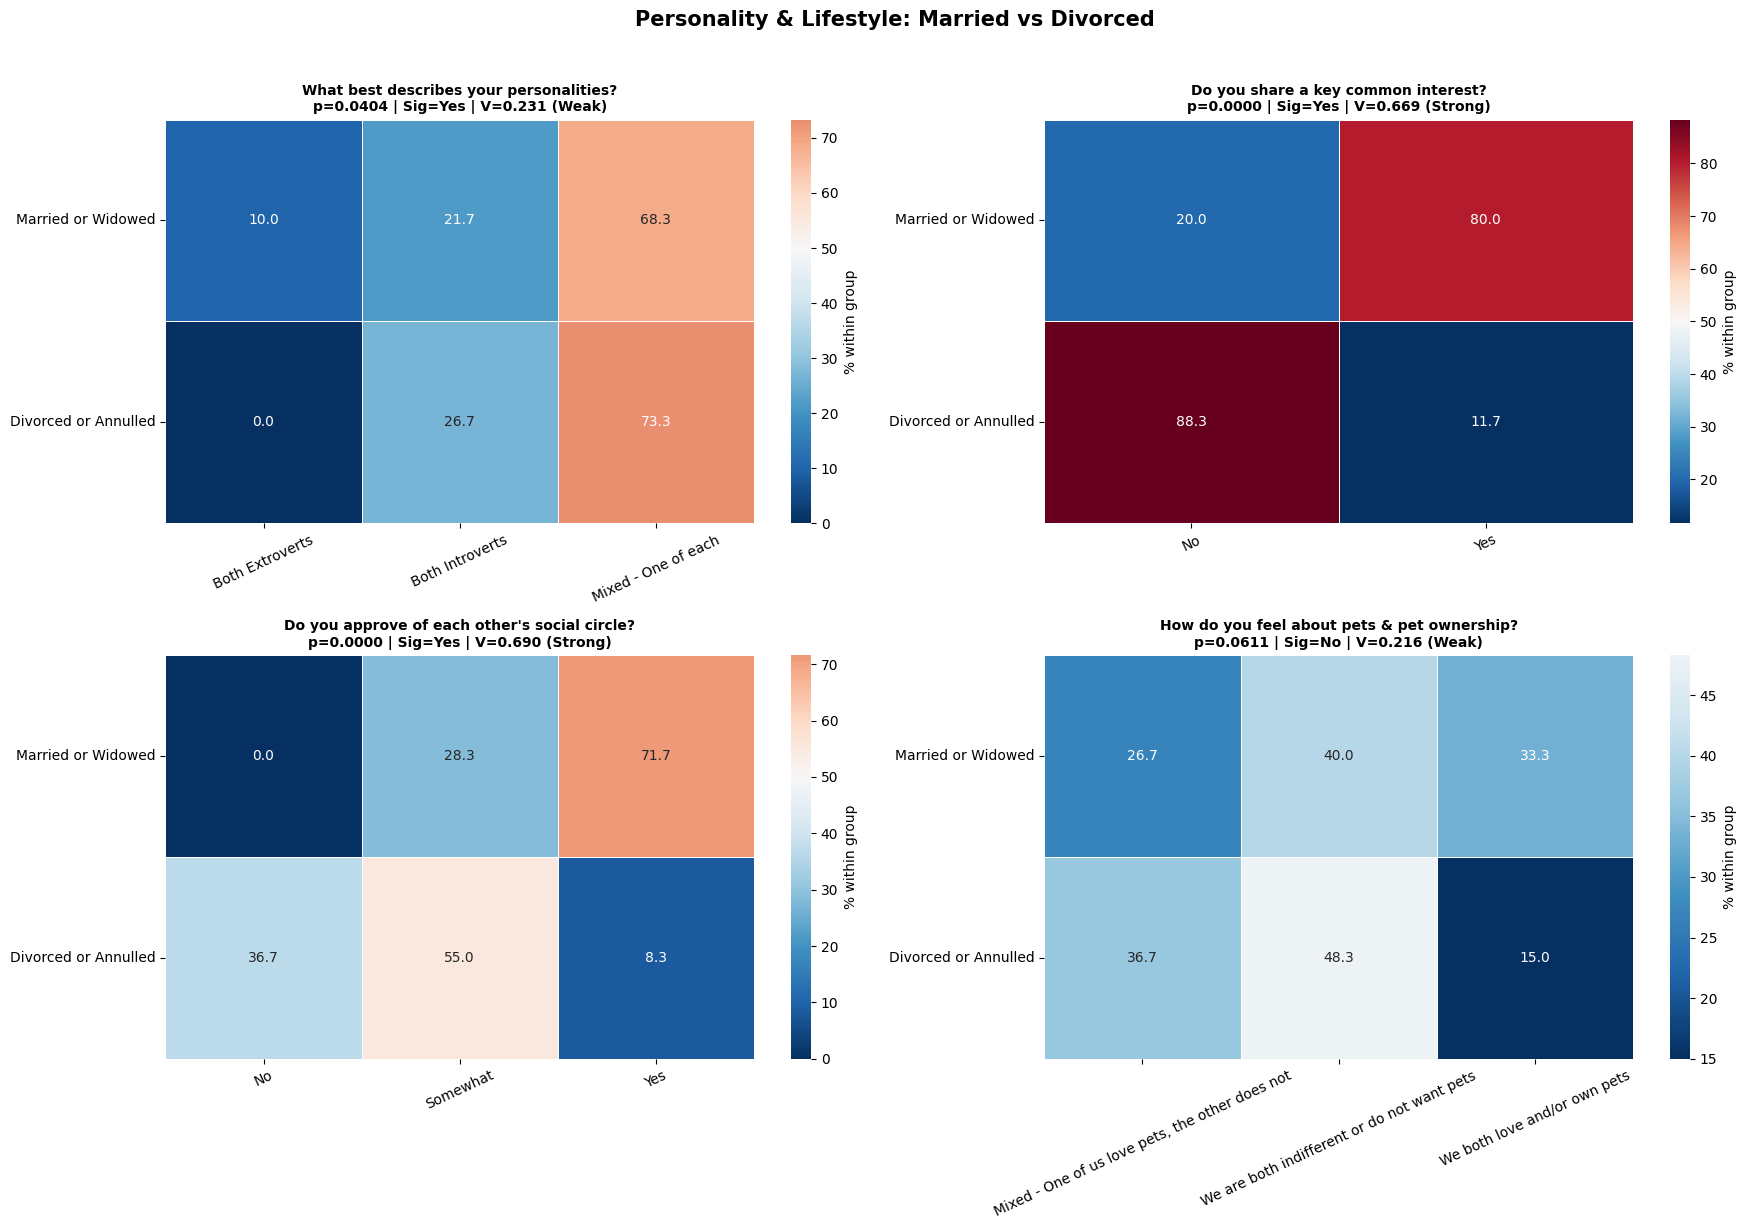


=== Noteworthy standardized residuals (|residual| > 1.5) ===

-- What best describes your personalities?
  Married or Widowed        | Both Extroverts                               : +1.73 (over-represented)
  Divorced or Annulled      | Both Extroverts                               : -1.73 (under-represented)

-- Do you share a key common interest?
  Married or Widowed        | No                                            : -3.60 (under-represented)
  Married or Widowed        | Yes                                           : +3.91 (over-represented)
  Divorced or Annulled      | No                                            : +3.60 (over-represented)
  Divorced or Annulled      | Yes                                           : -3.91 (under-represented)

-- Do you approve of each other's social circle?
  Married or Widowed        | No                                            : -3.32 (under-represented)
  Married or Widowed        | Somewhat                                      : -

In [36]:

status_col = 'What is your current marital status?'
status_order = ['Married or Widowed', 'Divorced or Annulled']

lifestyle_cols = {
    'personality': 'What best describes your personalities?',
    'common_interest': 'Do you share a key common interest?',
    'social_circle': "Do you approve of each other's social circle?",
    'pets': 'How do you feel about pets & pet ownership?'
}

def effect_label(v):
    if pd.isna(v):
        return 'N/A'
    if v >= 0.5:
        return 'Strong'
    if v >= 0.3:
        return 'Moderate'
    if v >= 0.1:
        return 'Weak'
    return 'Negligible'

def chi2_report(df, feature, target=status_col):
    sub = df[[feature, target]].dropna().copy()
    sub[feature] = sub[feature].astype(str).str.strip()

    ct = pd.crosstab(sub[target], sub[feature]).reindex(status_order).fillna(0).astype(int)

    if ct.shape[0] < 2 or ct.shape[1] < 2 or ct.to_numpy().sum() == 0:
        return None, None, {
            'Column': feature,
            'Chi2': np.nan,
            'p-value': np.nan,
            "Cramér's V": np.nan,
            'Effect': 'N/A',
            'Significant (p<0.05)': 'N/A',
            'Low expected (<5)': 'N/A'
        }

    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    return ct, pct, {
        'Column': feature,
        'Chi2': round(chi2, 3),
        'p-value': round(p, 4),
        "Cramér's V": round(v, 3),
        'Effect': effect_label(v),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No',
        'Low expected (<5)': 'Warn' if (expected < 5).any() else ''
    }

# --- A) Stats table + counts/% for each question ---
summary = []

for _, col in lifestyle_cols.items():
    ct, pct, row = chi2_report(divorced, col)
    summary.append(row)

    print(f"\n{'='*95}\n{col}\n{'='*95}")
    if ct is None:
        print("Not enough category variation for chi-square.")
        continue

    print("\nCount by marital status:")
    print(ct.to_string())

    print("\n% within marital-status group:")
    print(pct.round(1).to_string())

summary_df = pd.DataFrame(summary).sort_values(
    by=["Cramér's V", "p-value"],
    ascending=[False, True]
)

print("\n\n=== Lifestyle Questions: Married vs Divorced (ranked by Cramér's V) ===")
print(summary_df.to_string(index=False))
display(summary_df)

# --- B) Visuals: heatmaps of % within group ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (_, col) in zip(axes, lifestyle_cols.items()):
    ct, pct, row = chi2_report(divorced, col)

    if ct is None:
        ax.set_visible(False)
        continue

    sns.heatmap(
        pct,
        ax=ax,
        annot=True,
        fmt='.1f',
        cmap='RdBu_r',
        center=50,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': '% within group'}
    )

    v_val = row["Cramér's V"]
    ax.set_title(
        f"{col}\np={row['p-value']:.4f} | Sig={row['Significant (p<0.05)']} | "
        f"V={v_val:.3f} ({row['Effect']})",
        fontsize=10,
        fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Personality & Lifestyle: Married vs Divorced", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- C) Optional: strongest cells via standardized residuals ---
print("\n=== Noteworthy standardized residuals (|residual| > 1.5) ===")

for _, col in lifestyle_cols.items():
    sub = divorced[[status_col, col]].dropna().copy()
    sub[col] = sub[col].astype(str).str.strip()

    ct = pd.crosstab(sub[status_col], sub[col]).reindex(status_order).fillna(0).astype(int)

    if ct.shape[0] < 2 or ct.shape[1] < 2 or ct.to_numpy().sum() == 0:
        print(f"\n-- {col}")
        print("  Not enough category variation.")
        continue

    chi2, p, dof, expected = chi2_contingency(ct)
    std_resid = (ct.values - expected) / np.sqrt(expected)
    sr = pd.DataFrame(std_resid, index=ct.index, columns=ct.columns)

    print(f"\n-- {col}")
    hit = False
    for r in sr.index:
        for c in sr.columns:
            val = sr.loc[r, c]
            if abs(val) > 1.5:
                hit = True
                direction = 'over-represented' if val > 0 else 'under-represented'
                print(f"  {r:25s} | {c:45s} : {val:+.2f} ({direction})")
    if not hit:
        print("  No notable cells.")


### 5.1 Lifestyle takeaway
The strongest effects in this block are observed for:
- Approval of each other’s social circle
- Sharing a key common interest

## 6) Top-3 Values Analysis
This section transforms free-text top-3 values responses into structured features for downstream modelling.

Flow:
1. Quality-check and parse responses
2. Build overlap-based alignment features
3. Engineer per-value alignment/mismatch indicators
4. Explore higher-order value interactions

In [37]:
# --- Fixed columns ---
me_col = "Which top 3 values do you prioritise most in your life? [Me]"
spouse_col = "Which top 3 values do you prioritise most in your life? [My spouse/ex]"
value_cols = [me_col, spouse_col]

missing_cols = [c for c in value_cols if c not in divorced.columns]
if missing_cols:
    raise ValueError(f"Missing expected column(s): {missing_cols}")

def split_by_comma(text):
    if pd.isna(text):
        return []
    s = str(text).strip().lower()
    if not s:
        return []
    vals = [x.strip() for x in s.split(",") if x.strip()]
    # keep order, deduplicate
    out = []
    for v in vals:
        if v not in out:
            out.append(v)
    return out

def analyse_values_column(df, col):
    s = df[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan, "": np.nan})
    tmp = pd.DataFrame({col: s})
    tmp["is_missing"] = tmp[col].isna()

    # Comma rule: 3 values => exactly 2 commas
    tmp["comma_count"] = tmp[col].fillna("").str.count(",")
    tmp["n_by_comma_rule"] = np.where(tmp["is_missing"], 0, tmp["comma_count"] + 1)
    tmp["comma_rule_not_3"] = (~tmp["is_missing"]) & (tmp["comma_count"] != 2)

    # Top raw responses
    raw_top = s.value_counts(dropna=True).head(15).to_frame("count")

    # Top individual values (comma-split only)
    token_counter = Counter()
    for vals in tmp[col].apply(split_by_comma):
        token_counter.update(vals)
    token_top = pd.DataFrame(token_counter.most_common(20), columns=["value", "count"])

    # Summary
    n_total = len(tmp)
    n_non_missing = int((~tmp["is_missing"]).sum())
    n_missing = int(tmp["is_missing"].sum())
    n_no_comma = int(((~tmp["is_missing"]) & (tmp["comma_count"] == 0)).sum())
    n_comma_not_3 = int(tmp["comma_rule_not_3"].sum())

    summary = {
        "column": col,
        "rows_total": n_total,
        "non_missing": n_non_missing,
        "missing": n_missing,
        "non_missing_no_comma": n_no_comma,
        "comma_rule_not_3": n_comma_not_3,
        "pct_comma_rule_not_3": round((n_comma_not_3 / n_non_missing * 100), 1) if n_non_missing else np.nan,
    }

    return tmp, raw_top, token_top, summary

all_summaries = []

for col in value_cols:
    print("\n" + "=" * 100)
    print(f"COLUMN: {col}")
    print("=" * 100)

    tmp, raw_top, token_top, summary = analyse_values_column(divorced, col)
    all_summaries.append(summary)

    print("\nTop 15 most common raw responses:")
    display(raw_top)

    print("\nTop 20 most common individual values (comma-split):")
    display(token_top)

    print("\nCount selected (comma rule: commas + 1):")
    display(tmp.loc[~tmp["is_missing"], "n_by_comma_rule"].value_counts().sort_index().to_frame("count"))

    print("\nExamples of discrepant rows (comma_count != 2):")
    display(tmp.loc[tmp["comma_rule_not_3"], [col, "comma_count", "n_by_comma_rule"]].head(15))

summary_df = pd.DataFrame(all_summaries)
print("\n" + "=" * 100)
print("DISCREPANCY SUMMARY (COMMA RULE ONLY)")
print("=" * 100)
display(summary_df)


COLUMN: Which top 3 values do you prioritise most in your life? [Me]

Top 15 most common raw responses:


,count
Which top 3 values do you prioritise most in your life? [Me],
"Career Ambition, Family, Security/Stability",8
"Career Ambition, Family, Faith and Spirituality",6
Family,5
"Family, Travel, Health and Fitness",4
"Family, Faith and Spirituality, Community",3
"Family, Faith and Spirituality, Security/Stability",3
"Career Ambition, Family, Self-Improvement",3
"Career Ambition, Family, Security/Stability, Self-Improvement, Travel, Health and Fitness",2
"Career Ambition, Family, Travel",2



Top 20 most common individual values (comma-split):


,value,count
0,family,75
1,career ambition,50
2,security/stability,46
3,faith and spirituality,42
4,travel,39
5,adventure/trying new things,34
6,self-improvement,33
7,health and fitness,29
8,community,10



Count selected (comma rule: commas + 1):


...

,count
n_by_comma_rule,
1,9
2,2
3,102
4,5
5,1
6,1



Examples of discrepant rows (comma_count != 2):


,Which top 3 values do you prioritise most in your life? [My spouse/ex],comma_count,n_by_comma_rule
7,"Career Ambition, Faith and Spirituality, Self-...",3,4
8,Career Ambition,0,1
9,"Career Ambition, Family, Adventure/Trying New ...",3,4
10,Family,0,1
13,Family,0,1
14,Family,0,1
18,"Career Ambition, Faith and Spirituality, Secur...",3,4
22,"Travel, Health and Fitness",1,2
28,"Career Ambition, Security/Stability, Self-Impr...",3,4
30,Family,0,1



DISCREPANCY SUMMARY (COMMA RULE ONLY)


,column,rows_total,non_missing,missing,non_missing_no_comma,comma_rule_not_3,pct_comma_rule_not_3
0,Which top 3 values do you prioritise most in y...,120,120,0,7,19,15.8
1,Which top 3 values do you prioritise most in y...,120,120,0,9,18,15.0


### 6.1 Values overlap features
We compute overlap counts and bucket indicators (`overlap_0` to `overlap_3`) to represent value alignment at couple level.

In [38]:
# Reuse existing column names
me_col = "Which top 3 values do you prioritise most in your life? [Me]"
spouse_col = "Which top 3 values do you prioritise most in your life? [My spouse/ex]"

def split_by_comma(text):
    if pd.isna(text):
        return []
    vals = [x.strip().lower() for x in str(text).split(",") if x.strip()]
    # deduplicate while keeping order
    out = []
    for v in vals:
        if v not in out:
            out.append(v)
    return out

# Token sets (comma-only)
me_sets = divorced[me_col].apply(lambda x: set(split_by_comma(x)))
spouse_sets = divorced[spouse_col].apply(lambda x: set(split_by_comma(x)))

# Overlap count
divorced["values_overlap_count"] = [len(a & b) for a, b in zip(me_sets, spouse_sets)]

# Four overlap indicator columns
divorced["overlap_0"] = (divorced["values_overlap_count"] == 0).astype(int)
divorced["overlap_1"] = (divorced["values_overlap_count"] == 1).astype(int)
divorced["overlap_2"] = (divorced["values_overlap_count"] == 2).astype(int)
divorced["overlap_3"] = (divorced["values_overlap_count"] >= 3).astype(int)  # use ==3 if you want exact 3 only

# Quick check
display(
    divorced[
        [me_col, spouse_col, "values_overlap_count", "overlap_0", "overlap_1", "overlap_2", "overlap_3"]
    ].head(10)
)


,Which top 3 values do you prioritise most in your life? [Me],Which top 3 values do you prioritise most in your life? [My spouse/ex],values_overlap_count,overlap_0,overlap_1,overlap_2,overlap_3
0,"Self-Improvement, Health and Fitness, Community","Career Ambition, Family, Security/Stability",0,1,0,0,0
1,"Career Ambition, Family, Security/Stability","Family, Security/Stability, Health and Fitness",2,0,0,1,0
2,"Family, Faith and Spirituality, Security/Stabi...","Career Ambition, Adventure/Trying New Things, ...",0,1,0,0,0
3,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Self-Improvement",2,0,0,1,0
4,"Career Ambition, Family, Faith and Spirituality","Career Ambition, Family, Faith and Spirituality",3,0,0,0,1
5,"Career Ambition, Family, Security/Stability","Family, Adventure/Trying New Things, Travel",1,0,1,0,0
6,"Career Ambition, Family, Health and Fitness","Career Ambition, Family, Health and Fitness",3,0,0,0,1
7,"Family, Faith and Spirituality, Adventure/Tryi...","Career Ambition, Faith and Spirituality, Self-...",1,0,1,0,0
8,Faith and Spirituality,Career Ambition,0,1,0,0,0
9,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Adventure/Trying New ...",4,0,0,0,1


In [39]:
status_col = "What is your current marital status?"
status_order = ["Married or Widowed", "Divorced or Annulled"]
overlap_cols = ["overlap_0", "overlap_1", "overlap_2", "overlap_3"]

# Count rows in each overlap bucket, split by marital status
overlap_counts = (
    divorced.groupby(status_col)[overlap_cols]
    .sum()
    .reindex(status_order)
    .astype(int)
)

# Optional: % within each marital-status group
overlap_pct = overlap_counts.div(overlap_counts.sum(axis=1), axis=0).mul(100).round(1)

print("=== Overlap counts by marital status ===")
display(overlap_counts)

print("=== Overlap % within marital status ===")
display(overlap_pct)

# Optional sanity check: each row should belong to exactly one overlap bucket
row_bucket_sum = divorced[overlap_cols].sum(axis=1)
print("Rows not in exactly one overlap bucket:", int((row_bucket_sum != 1).sum()))


=== Overlap counts by marital status ===


,overlap_0,overlap_1,overlap_2,overlap_3
What is your current marital status?,,,,
Married or Widowed,6,15,22,17
Divorced or Annulled,14,26,17,3


=== Overlap % within marital status ===


,overlap_0,overlap_1,overlap_2,overlap_3
What is your current marital status?,,,,
Married or Widowed,10.0,25.0,36.7,28.3
Divorced or Annulled,23.3,43.3,28.3,5.0


Rows not in exactly one overlap bucket: 0


### 6.2 Advanced value engineering for modelling
Beyond overlap counts, this block creates per-value presence, alignment/mismatch, and similarity metrics (e.g., jaccard/cosine) plus candidate interactions.

In [40]:
status_col = "What is your current marital status?"
me_col = "Which top 3 values do you prioritise most in your life? [Me]"
spouse_col = "Which top 3 values do you prioritise most in your life? [My spouse/ex]"

def parse_values(x):
    if pd.isna(x):
        return set()
    vals = [v.strip().lower() for v in str(x).split(",") if v.strip()]
    return set(vals)

def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

# Parse sets
divorced["me_values_set"] = divorced[me_col].apply(parse_values)
divorced["spouse_values_set"] = divorced[spouse_col].apply(parse_values)

# Universe of values
all_values = sorted(set().union(*divorced["me_values_set"], *divorced["spouse_values_set"]))

# Per-value engineered features
for v in all_values:
    k = slug(v)
    m = divorced["me_values_set"].apply(lambda s: int(v in s))
    s = divorced["spouse_values_set"].apply(lambda s: int(v in s))
    divorced[f"me_has__{k}"] = m
    divorced[f"spouse_has__{k}"] = s
    divorced[f"both_have__{k}"] = ((m == 1) & (s == 1)).astype(int)
    divorced[f"mismatch__{k}"] = ((m + s) == 1).astype(int)

# Similarity summary features
overlap = divorced.apply(lambda r: len(r["me_values_set"] & r["spouse_values_set"]), axis=1)
union = divorced.apply(lambda r: len(r["me_values_set"] | r["spouse_values_set"]), axis=1)
me_n = divorced["me_values_set"].apply(len)
sp_n = divorced["spouse_values_set"].apply(len)

divorced["values_overlap_count"] = overlap
divorced["values_union_count"] = union
divorced["values_mismatch_count"] = union - overlap
divorced["values_jaccard"] = np.where(union > 0, overlap / union, 0.0)
divorced["values_cosine"] = np.where((me_n > 0) & (sp_n > 0), overlap / np.sqrt(me_n * sp_n), 0.0)

print(f"Engineered {len(all_values)} unique values.")
print("Example value keys:", [slug(v) for v in all_values[:10]])


Engineered 9 unique values.
Example value keys: ['adventure_trying_new_things', 'career_ambition', 'community', 'faith_and_spirituality', 'family', 'health_and_fitness', 'security_stability', 'self_improvement', 'travel']


In [41]:
status_col = "What is your current marital status?"
y = divorced[status_col].map({
    "Married or Widowed": 0,
    "Divorced or Annulled": 1
})

# Use alignment-focused features only
base_cols = [c for c in divorced.columns if c.startswith(("both_have__", "mismatch__"))]

# Keep only reasonably common features to reduce sparse/noisy interactions
prev = divorced[base_cols].mean()
candidate_cols = prev[(prev >= 0.08) & (prev <= 0.92)].sort_values(ascending=False).head(30).index.tolist()

rows = []
for a, b in itertools.combinations(candidate_cols, 2):
    inter = (divorced[a].astype(int) & divorced[b].astype(int)).astype(int)
    n_pos = int(inter.sum())
    if n_pos < 5:  # skip very rare interaction
        continue

    ct = pd.crosstab(inter, y).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    chi2, p, _, expected = chi2_contingency(ct)

    # OR for divorce when interaction=1 (with Haldane correction)
    a11 = ct.loc[1, 1]  # inter=1, divorced=1
    a10 = ct.loc[1, 0]  # inter=1, married=0
    a01 = ct.loc[0, 1]
    a00 = ct.loc[0, 0]
    or_div = ((a11 + 0.5) * (a00 + 0.5)) / ((a10 + 0.5) * (a01 + 0.5))

    rows.append({
        "feature_a": a,
        "feature_b": b,
        "interaction": f"{a}__AND__{b}",
        "n_interaction_1": n_pos,
        "divorce_rate_when_1": round(a11 / max(a11 + a10, 1), 3),
        "odds_ratio_divorce": round(or_div, 3),
        "p_value": round(p, 5),
        "low_expected_flag": "⚠️" if (expected < 5).any() else ""
    })

interactions_df = pd.DataFrame(rows)
if interactions_df.empty:
    print("No eligible interactions found after prevalence/rarity filters.")
else:
    interactions_df["abs_log_or"] = np.abs(np.log(interactions_df["odds_ratio_divorce"]))
    interactions_df = interactions_df.sort_values(
        ["p_value", "abs_log_or", "n_interaction_1"],
        ascending=[True, False, False]
    )

    print(f"Candidate base features: {len(candidate_cols)}")
    print(f"Tested interactions: {len(interactions_df)}")

    print

Candidate base features: 17
Tested interactions: 77


## 8) Optional Open-Response Analysis
This section analyses the optional final free-text question to understand:
- how many respondents provided comments,
- what those comments were,
- how responses differ by marital-status group,
- and overall sentiment patterns.

In [42]:
# Part 8: Optional open-response analysis from original responses file
orig_path = r"/Users/clairesng/Downloads/capstone - divorced/original_responses.csv"
orig = pd.read_csv(orig_path, encoding="latin1")

status_col = "What is your current marital status?"
open_resp_col_candidates = [
    c for c in orig.columns
    if "Thank you for reaching the end" in c
    and "important for a relationship" in c
]

if not open_resp_col_candidates:
    raise ValueError("Optional open-response column not found in original_responses.csv")

open_resp_col = open_resp_col_candidates[0]

open_df = orig[[status_col, open_resp_col]].copy().rename(columns={
    status_col: "marital_status",
    open_resp_col: "optional_open_response"
})

# Clean missing-like responses
missing_like = {"", "nan", "none", "n/a", "na", "nil", "-"}
open_df["response_text"] = open_df["optional_open_response"].astype(str).str.strip()
open_df.loc[open_df["response_text"].str.lower().isin(missing_like), "response_text"] = np.nan

responses_df = open_df[open_df["response_text"].notna()].copy()
responses_df = responses_df[["marital_status", "response_text"]].reset_index(drop=True)

print("=== Optional Open Response (from original_responses.csv) ===")
print(f"Total rows: {len(open_df)}")
print(f"Non-empty responses: {len(responses_df)}")
print(f"Response rate: {len(responses_df)/len(open_df):.1%}")

print("\n=== Response counts by marital status ===")
display(
    responses_df["marital_status"]
    .value_counts()
    .rename_axis("marital_status")
    .reset_index(name="n")
)

print("\n=== All optional responses with marital status ===")
display(responses_df)

# Recurring words/themes
stopwords = {
    "the","and","or","to","of","a","in","for","is","are","we","it","on","that",
    "with","be","as","our","you","your","they","them","this","too","if","was",
    "have","had","not","do","does","so","but","at","by","an","from","when",
    "who","how","what","where","will","would","can","could","should","there","their",
    "otherwise","press","submit","need","needs","sometimes","getting","before","after",
    "one","us"
}

def _clean_text(t):
    s = str(t).lower()
    s = s.replace("child(ren)", "children")
    return s

def tokenize(text):
    text = _clean_text(text)
    tokens = re.findall(r"[a-zA-Z']+", text)
    return [t for t in tokens if len(t) > 2 and t not in stopwords]

all_tokens = []
for txt in responses_df["response_text"]:
    all_tokens.extend(tokenize(txt))

word_freq = pd.DataFrame(Counter(all_tokens).most_common(20), columns=["word", "count"])
print("\n=== Top recurring words (overall) ===")
display(word_freq)

# Theme buckets (keyword-based)
theme_map = {
    "communication": ["communication", "communicate", "discussion", "discussions"],
    "trust": ["trust"],
    "respect": ["respect"],
    "commitment": ["commitment", "committed"],
    "compromise_alignment": ["compromise", "aligned", "alignment"],
    "family_children": ["family", "child", "children", "baby", "parents"],
    "intimacy": ["sex"],
    "education": ["education"],
    "religion_values": ["belief", "beliefs", "values", "religion", "soulmates", "politics"],
}

def detect_themes(text):
    toks = set(tokenize(text))
    hits = []
    for theme, kws in theme_map.items():
        for kw in kws:
            if any(tok.startswith(kw) for tok in toks):
                hits.append(theme)
                break
    return hits if hits else ["other"]

responses_df["themes"] = responses_df["response_text"].apply(detect_themes)

theme_rows = []
for _, r in responses_df.iterrows():
    for th in r["themes"]:
        theme_rows.append({
            "marital_status": r["marital_status"],
            "theme": th
        })

themes_long = pd.DataFrame(theme_rows)
theme_counts = themes_long["theme"].value_counts().rename_axis("theme").reset_index(name="n")
theme_by_status = themes_long.groupby(["marital_status", "theme"]).size().unstack(fill_value=0)

print("\n=== Recurring themes (overall) ===")
display(theme_counts)

print("\n=== Recurring themes by marital status ===")
display(theme_by_status)

print("\n=== Responses with detected themes ===")
display(responses_df[["marital_status", "response_text", "themes"]])

FileNotFoundError: [Errno 2] No such file or directory: '/Users/clairesng/Downloads/capstone - divorced/original_responses.csv'